# Power Generation Forecasting and Analysis Using CEA Monthly Generation Reports

### Project Overview

This project focuses on analyzing and forecasting power generation in India using monthly generation reports published by the Central Electricity Authority (CEA). The dataset contains region-wise statistics for Thermal, Hydro, and Nuclear power generation from January 2022 to May 2026.

The project involves automated data collection, data cleaning, exploratory data analysis, feature engineering, and time-series forecasting. The objective is to identify historical generation patterns, understand regional and source-wise trends, and develop predictive models to estimate future power generation. The insights generated can support energy planning, resource management, and decision-making in the power sector.


### Step 1: Data Collection
The first step of the project involves collecting historical power generation data from the National Power Portal (NPP), maintained by the Central Electricity Authority (CEA), Government of India. The portal provides monthly generation reports containing detailed statistics on electricity generation across different regions of India.

To automate the collection process, a Python script was developed to download region-wise Excel reports for the period January 2022 to May 2026. The script dynamically generates report URLs based on the year and month, sends HTTP requests to retrieve the files, and stores them in a local directory for further processing.

The downloaded reports contain generation data for Thermal, Hydro, and Nuclear power sources, along with information such as monitored capacity, target generation, actual generation, previous year generation, and Plant Load Factor (PLF). Automating the data collection process ensures consistency, reduces manual effort, and enables efficient handling of a large number of monthly reports.


In [2]:
#Import Library
import os
import requests
from time import sleep

In [3]:
#Set Configs
START_YEAR = 2022
END_YEAR = 2026

DOWNLOAD_FOLDER = "region_wise_reports"

os.makedirs(DOWNLOAD_FOLDER, exist_ok=True)

months = {
    1: "JAN",
    2: "FEB",
    3: "MAR",
    4: "APR",
    5: "MAY",
    6: "JUN",
    7: "JUL",
    8: "AUG",
    9: "SEP",
    10: "OCT",
    11: "NOV",
    12: "DEC"
}
base_url = (
    "https://npp.gov.in/public-reports/cea/monthly/generation/"
)


In [4]:
#For Downlaoding the files
for year in range(START_YEAR, END_YEAR + 1):

    for month_num, month_name in months.items():

        # Stop after May 2026
        if year == 2026 and month_num > 5:
            break

        print(f"Processing: {month_name}-{year}")

        # REGION WISE FILE
        # -2 = Region Wise

        file_name = (
            f"18_col_act-2_{year}-{month_name}.xls"
        )

        url = (
            f"{base_url}"
            f"18_col_act/{year}/{month_name}//{file_name}"
        )

        print("Trying:")
        print(url)

        try:

            response = requests.get(url, timeout=30)

            if response.status_code == 200:

                save_path = os.path.join(
                    DOWNLOAD_FOLDER,
                    file_name
                )

                with open(save_path, "wb") as f:
                    f.write(response.content)

                print(f"Downloaded: {file_name}")

            else:

                print(
                    f"Failed: {response.status_code}"
                )

        except Exception as e:

            print("ERROR:", e)

        sleep(1)

print("\nALL DOWNLOADS COMPLETED")

Processing: JAN-2022
Trying:
https://npp.gov.in/public-reports/cea/monthly/generation/18_col_act/2022/JAN//18_col_act-2_2022-JAN.xls
Downloaded: 18_col_act-2_2022-JAN.xls
Processing: FEB-2022
Trying:
https://npp.gov.in/public-reports/cea/monthly/generation/18_col_act/2022/FEB//18_col_act-2_2022-FEB.xls
Downloaded: 18_col_act-2_2022-FEB.xls
Processing: MAR-2022
Trying:
https://npp.gov.in/public-reports/cea/monthly/generation/18_col_act/2022/MAR//18_col_act-2_2022-MAR.xls
Downloaded: 18_col_act-2_2022-MAR.xls
Processing: APR-2022
Trying:
https://npp.gov.in/public-reports/cea/monthly/generation/18_col_act/2022/APR//18_col_act-2_2022-APR.xls
Downloaded: 18_col_act-2_2022-APR.xls
Processing: MAY-2022
Trying:
https://npp.gov.in/public-reports/cea/monthly/generation/18_col_act/2022/MAY//18_col_act-2_2022-MAY.xls
Downloaded: 18_col_act-2_2022-MAY.xls
Processing: JUN-2022
Trying:
https://npp.gov.in/public-reports/cea/monthly/generation/18_col_act/2022/JUN//18_col_act-2_2022-JUN.xls
Downloaded: 

### Step 2:Data Merging and Consolidation

After collecting the monthly Excel reports, the next step is to combine the data from all files into a single structured dataset. Since each report contains region-wise generation statistics in a similar format, the reports can be processed and merged to create a unified dataset for analysis.

The Excel files are read individually, and relevant information such as Region, Category, Monitored Capacity, Target Generation, Actual Generation, Previous Year Generation, and Plant Load Factor (PLF) is extracted. Unnecessary rows, including empty rows and summary totals, are removed during this process.

Additionally, the reporting period (Year-Month) is extracted from each file name and added as a separate column to maintain the temporal sequence of the data. The cleaned records from all reports are then appended into a single DataFrame, resulting in a consolidated dataset containing historical power generation statistics across different regions and power categories.

This merged dataset provides a consistent and analysis-ready foundation for data cleaning, exploratory analysis, feature engineering, and forecasting.

In [5]:
# Import Libraries Required
import pandas as pd
import glob
import os
import re

# File Directory
files = glob.glob("region_wise_reports/*.xls")

In [7]:
all_data = []

for file in files:

    filename = os.path.basename(file)

    match = re.search(r'(\d{4}-[A-Z]{3})', filename)

    if match:
        period = match.group(1)
    else:
        period = None

    # Read Excel

    df = pd.read_excel(
        file,
        skiprows=12,
        header=None
    )

    current_region = None

    for _, row in df.iterrows():
        first_col = str(row[0]).strip().upper()
        # Skip empty rows

        if first_col == "NAN":
            continue

        # Detect region rows

        if "REGION" in first_col:

            current_region = first_col
            continue

        if "TOTAL" in first_col:
            continue

        # Keep category rows only

        if first_col in ["THERMAL", "HYDRO", "NUCLEAR"]:

            data = {

                "Period": period,
                "Region": current_region,
                "Category": first_col,

                # B
                "Monitored_Capacity": row[1],

                # C
                "Target": row[2],

                # D
                "Program_Generation": row[3],

                # E
                "Actual_Generation": row[4],

                # G
                "Percent_Last_Year": row[6],

                # H
                "Last_Year_Generation": row[7],

                # N
                "PLF_Program": row[13],

                # O
                "PLF_Actual": row[14]
            }

            all_data.append(data)

In [8]:
#Final DF
df = pd.DataFrame(all_data)
# Save dataset
df.to_csv("data.csv", index=False)

print(df.head())

     Period            Region Category  Monitored_Capacity    Target  \
0  2022-APR  NORTHERN  REGION  THERMAL            51660.26  273550.0   
1  2022-APR  NORTHERN  REGION  NUCLEAR             1620.00    9348.0   
2  2022-APR  NORTHERN  REGION    HYDRO            19576.27   76243.0   
3  2022-APR   WESTERN  REGION  THERMAL            96392.49  502787.0   
4  2022-APR   WESTERN  REGION  NUCLEAR             1840.00   14160.0   

   Program_Generation  Actual_Generation  Percent_Last_Year  \
0             22566.0           25146.03         111.433262   
1               768.0             907.12         118.114583   
2              4805.0            5519.12         114.862019   
3             44347.0           43682.94          98.502586   
4              1245.0            1101.47          88.471486   

   Last_Year_Generation PLF_Program PLF_Actual  
0            127.081240   62.553543   74.58152  
1             91.208172   70.175439  77.770919  
2            159.299479                  

### Step 3: Data Cleaning and Preprocessing

The merged dataset was cleaned to improve data quality and prepare it for analysis. Missing values, irrelevant rows, and inconsistencies were removed, while numerical columns were verified and standardized. The reporting period was also converted into a suitable date format for time-series analysis.

These preprocessing steps ensure that the dataset is accurate, consistent, and ready for further analysis and forecasting.

In [10]:
df.shape

(848, 11)

In [11]:
df.dtypes

Period                   object
Region                   object
Category                 object
Monitored_Capacity      float64
Target                  float64
Program_Generation      float64
Actual_Generation       float64
Percent_Last_Year       float64
Last_Year_Generation    float64
PLF_Program              object
PLF_Actual               object
dtype: object

In [12]:
df['Period'] = pd.to_datetime(df['Period'], errors="coerce")

C:\Users\Prajakta\AppData\Local\Temp\ipykernel_18636\702216925.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Period'] = pd.to_datetime(df['Period'], errors="coerce")


In [13]:
df["PLF_Program"] = pd.to_numeric(df["PLF_Program"], errors="coerce")

In [14]:
df["PLF_Actual"] = pd.to_numeric(df["PLF_Actual"], errors="coerce")

In [15]:
df.dtypes

Period                  datetime64[ns]
Region                          object
Category                        object
Monitored_Capacity             float64
Target                         float64
Program_Generation             float64
Actual_Generation              float64
Percent_Last_Year              float64
Last_Year_Generation           float64
PLF_Program                    float64
PLF_Actual                     float64
dtype: object

In [16]:
df[["Period", "Region", "Category"]].isnull().sum()

Period      0
Region      0
Category    0
dtype: int64

In [17]:
df.isnull().sum()

Period                    0
Region                    0
Category                  0
Monitored_Capacity        0
Target                    0
Program_Generation        0
Actual_Generation         0
Percent_Last_Year         1
Last_Year_Generation      0
PLF_Program             318
PLF_Actual              318
dtype: int64

In [18]:
df["Month"] = df["Period"].dt.month

In [19]:
df["Year"] = df["Period"].dt.year

### Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand the characteristics of the power generation dataset and identify important patterns, trends, and relationships. The analysis focused on examining generation levels across different regions and power categories, as well as observing changes over time.

Various statistical summaries and visualizations were used to explore the distribution of generation values, compare Thermal, Hydro, and Nuclear power generation, and identify seasonal or regional variations. EDA helps uncover meaningful insights from the data and provides a foundation for feature engineering and forecasting model development.


In [20]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

In [79]:
from sklearn.metrics import mean_absolute_percentage_error

In [23]:
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']
sns.set_palette(PALETTE)


In [21]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,Period,Monitored_Capacity,Target,Program_Generation,Actual_Generation,Percent_Last_Year,Last_Year_Generation,PLF_Program,PLF_Actual,Month,Year
count,848,848.000000,8.480000e+02,848.000000,848.000000,847.000000,848.000000,530.000000,530.000000,848.000000,848.000000
mean,2024-03-01 13:07:55.471698176,37108.326198,1.971040e+05,16402.547170,15652.543408,98.950389,106.772538,70.628202,71.348508,6.169811,2023.735849
min,2022-01-01 00:00:00,1620.000000,6.839000e+03,190.000000,216.970000,36.351351,34.675119,0.000000,46.194786,1.000000,2022.000000
25%,2023-02-01 00:00:00,3300.000000,1.618500e+04,1278.500000,1194.392500,87.461120,94.332575,63.505408,64.307435,3.000000,2023.000000
50%,2024-03-01 00:00:00,10259.750000,3.863650e+04,3300.500000,3386.955000,97.251120,103.423204,70.533582,71.134754,6.000000,2024.000000
75%,2025-04-01 00:00:00,49519.672500,2.550200e+05,22002.000000,20677.022500,108.497206,114.776767,78.779386,78.285461,9.000000,2025.000000
max,2026-05-01 00:00:00,250829.126000,1.503662e+06,135889.000000,127870.480000,212.122201,299.369173,111.486486,98.134021,12.000000,2026.000000
std,NaN,58880.358288,3.377408e+05,28289.103119,26756.496013,19.896327,27.145307,12.390323,9.893653,3.470154,1.291526


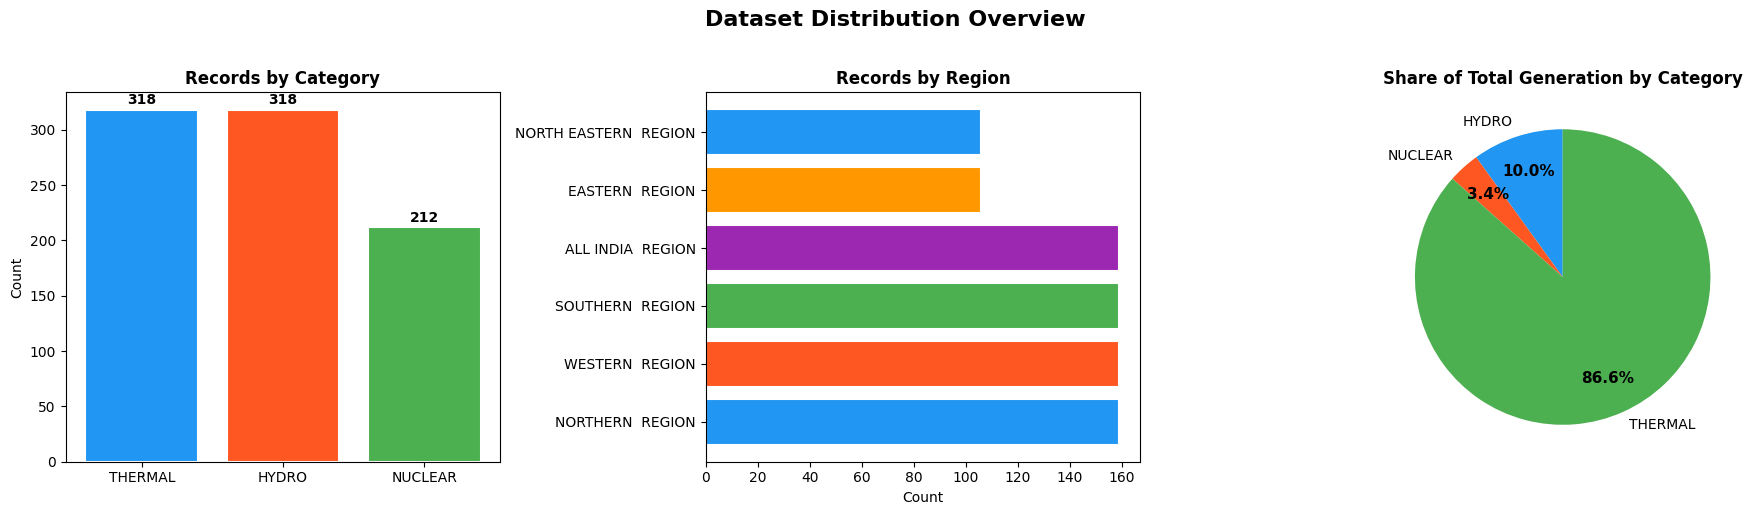

In [24]:
# Region & Category Distribution 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Category distribution
cat_counts = df['Category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color=PALETTE[:3], edgecolor='white', linewidth=1.5)
axes[0].set_title('Records by Category', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Region distribution
reg_counts = df['Region'].value_counts()
axes[1].barh(reg_counts.index, reg_counts.values, color=PALETTE[:5], edgecolor='white', linewidth=1.5)
axes[1].set_title('Records by Region', fontweight='bold')
axes[1].set_xlabel('Count')

# Total Actual Generation by Category
cat_gen = df.groupby('Category')['Actual_Generation'].sum() / 1e6
wedges, texts, autotexts = axes[2].pie(
    cat_gen.values, labels=cat_gen.index, autopct='%1.1f%%',
    colors=PALETTE[:3], startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[2].set_title('Share of Total Generation by Category', fontweight='bold')

plt.suptitle('Dataset Distribution Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Step 5: Univariate Analysis

Univariate Analysis was conducted to examine the distribution and characteristics of individual variables in the dataset. Summary statistics and visualizations were used to understand the behavior of key features such as Actual Generation, Target Generation, and Monitored Capacity.

In [25]:
vars_to_plot = [
    ('Actual_Generation',   '#2196F3', 'Actual Generation (MU)'),
    ('Program_Generation',  '#FF5722', 'Program Generation (MU)'),
    ('PLF_Actual',          '#4CAF50', 'PLF Actual (%)'),
    ('Target',              '#9C27B0', 'Target Generation (MU)'),
    ('Monitored_Capacity',  '#FF9800', 'Monitored Capacity (MW)'),
]


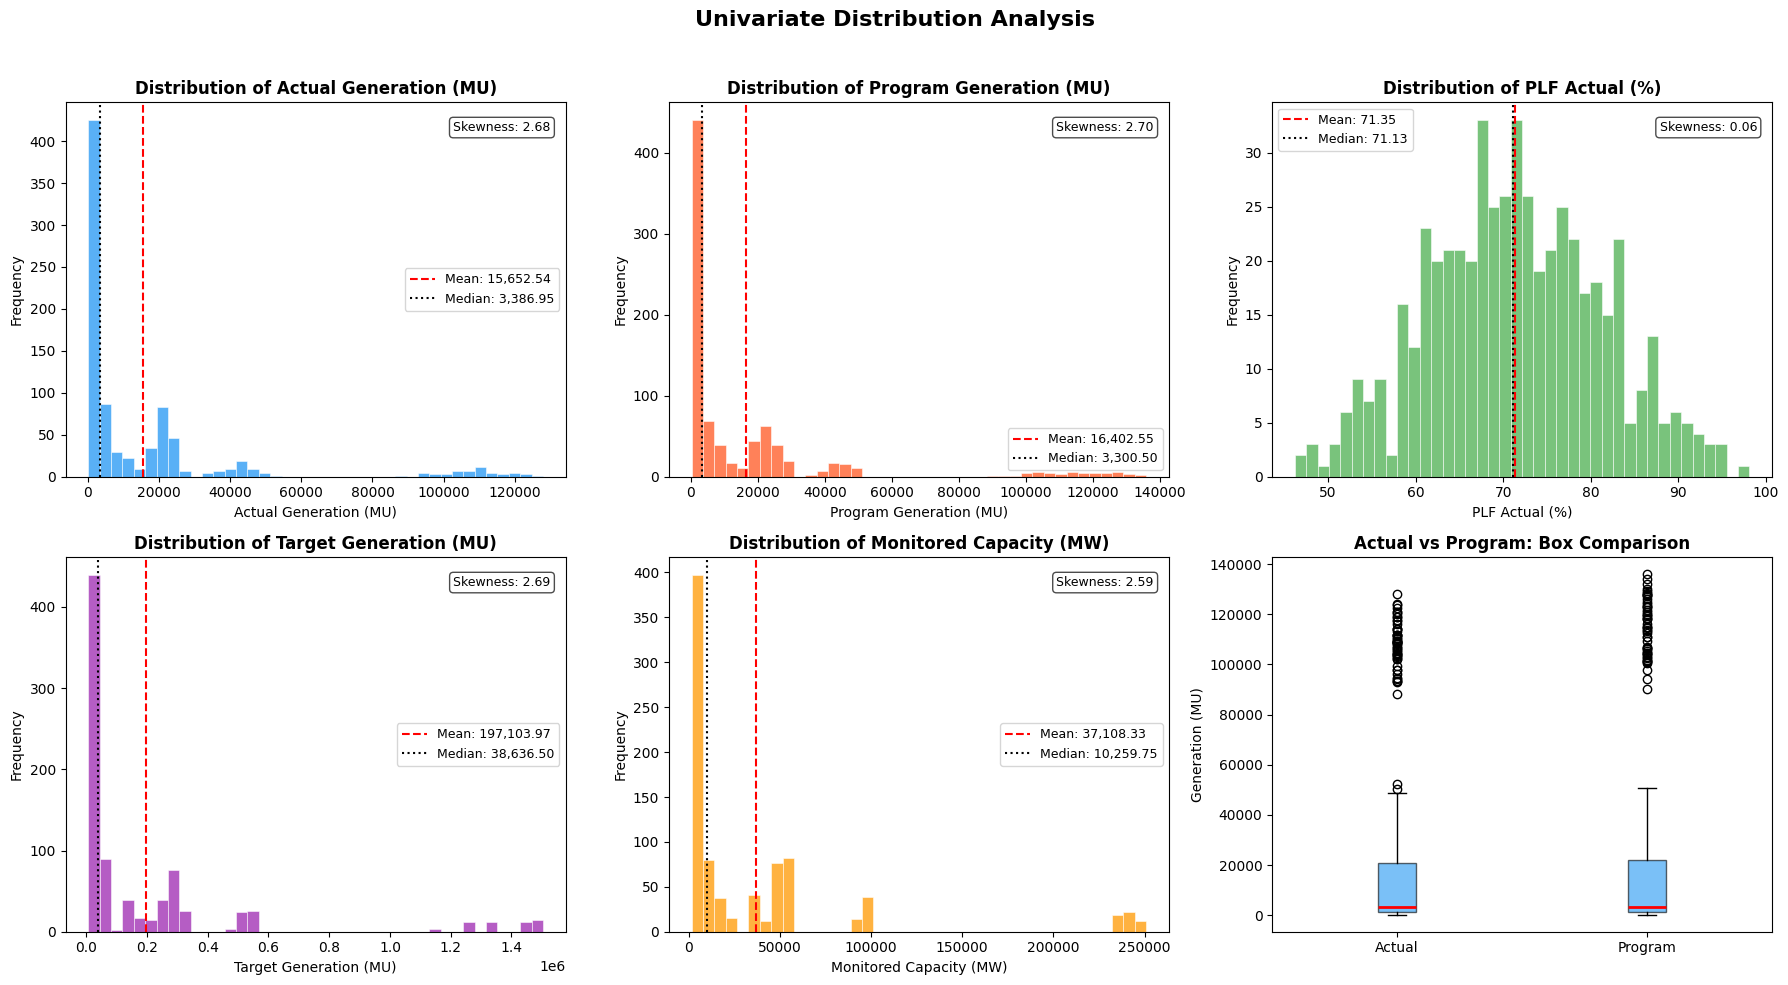

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (col, color, label) in enumerate(vars_to_plot):
    data = df[col].dropna()

    axes[i].hist(
        data,
        bins=40,
        color=color,
        alpha=0.75,
        edgecolor='white',
        linewidth=0.5
    )

    axes[i].axvline(
        data.mean(),
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Mean: {data.mean():,.2f}'
    )

    axes[i].axvline(
        data.median(),
        color='black',
        linestyle=':',
        linewidth=1.5,
        label=f'Median: {data.median():,.2f}'
    )

    axes[i].set_title(f'Distribution of {label}', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

    skew = data.skew()

    axes[i].text(
        0.97, 0.95,
        f'Skewness: {skew:.2f}',
        transform=axes[i].transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7)
    )

# Box Plot
axes[5].boxplot(
    [
        df['Actual_Generation'].dropna(),
        df['Program_Generation'].dropna()
    ],
    labels=['Actual', 'Program'],   # labels is deprecated
    patch_artist=True,
    boxprops=dict(facecolor='#2196F3', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)

axes[5].set_title('Actual vs Program: Box Comparison', fontweight='bold')
axes[5].set_ylabel('Generation (MU)')

plt.suptitle('Univariate Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

### Step 6: Bivariate Analysis

Bivariate Analysis was performed to examine the relationship between two variables and identify patterns or correlations within the dataset. Relationships between variables such as Monitored Capacity, Target Generation, Program Generation, and Actual Generation were analyzed using visualizations and correlation measures.

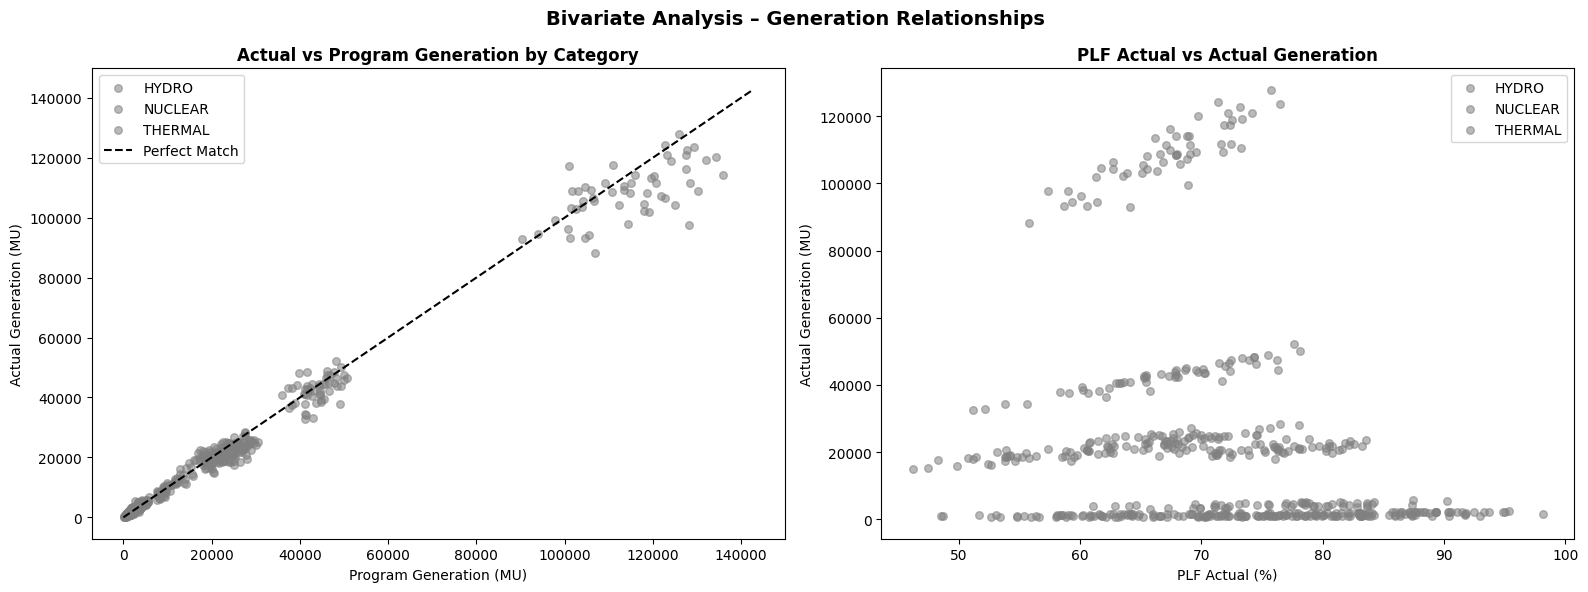

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_cat = {
    'Thermal': '#2196F3',
    'Hydro': '#4CAF50',
    'Nuclear': '#FF5722'
}

# Actual vs Program 
for cat, grp in df.groupby('Category'):

    axes[0].scatter(
        grp['Program_Generation'],
        grp['Actual_Generation'],
        label=cat,
        alpha=0.55,
        s=30,
        color=colors_cat.get(cat, 'gray')
    )

# Perfect line
lim = max(
    df['Program_Generation'].max(),
    df['Actual_Generation'].max()
) * 1.05

axes[0].plot(
    [0, lim],
    [0, lim],
    'k--',
    linewidth=1.5,
    label='Perfect Match'
)

axes[0].set_xlabel('Program Generation (MU)')
axes[0].set_ylabel('Actual Generation (MU)')
axes[0].set_title('Actual vs Program Generation by Category', fontweight='bold')
axes[0].legend()


#PLF vs Actual Generation
for cat, grp in df.groupby('Category'):

    axes[1].scatter(
        grp['PLF_Actual'],
        grp['Actual_Generation'],
        label=cat,
        alpha=0.55,
        s=30,
        color=colors_cat.get(cat, 'gray')
    )

axes[1].set_xlabel('PLF Actual (%)')
axes[1].set_ylabel('Actual Generation (MU)')
axes[1].set_title('PLF Actual vs Actual Generation', fontweight='bold')
axes[1].legend()

plt.suptitle(
    'Bivariate Analysis – Generation Relationships',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

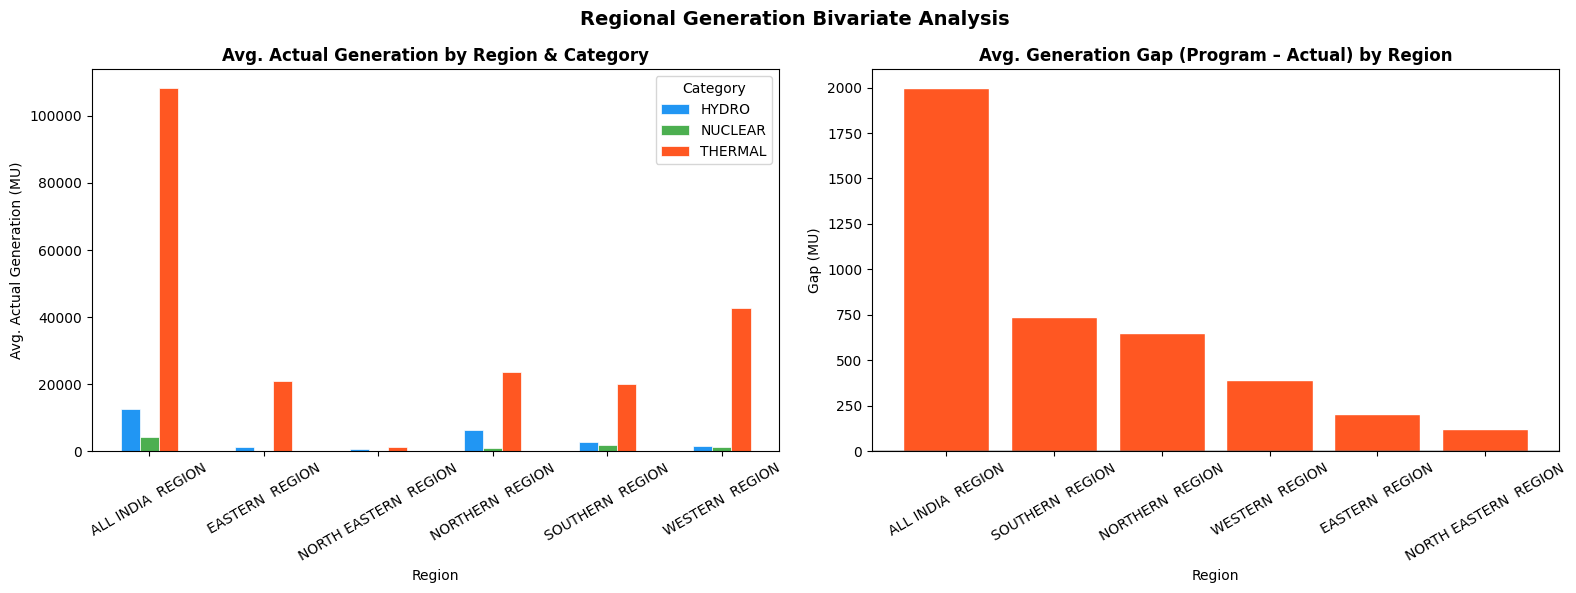

In [30]:
#Regional Generation Bivariate Analysis
fig, axes = plt.subplots(1,2, figsize=(16, 6))

# Average Actual Generation by Region & Category
pivot_reg = df.groupby(['Region', 'Category'])['Actual_Generation'].mean().unstack()
pivot_reg.plot(kind='bar', ax=axes[0], color=list(colors_cat.values()), edgecolor='white', linewidth=0.5)
axes[0].set_title('Avg. Actual Generation by Region & Category', fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Avg. Actual Generation (MU)')
axes[0].legend(title='Category')
axes[0].tick_params(axis='x', rotation=30)

# Performance Gap (Program vs Actual) by Region
df['Generation_Gap'] = df['Program_Generation'] - df['Actual_Generation']
gap_region = df.groupby('Region')['Generation_Gap'].mean().sort_values(ascending=False)
colors_gap = ['#FF5722' if v > 0 else '#4CAF50' for v in gap_region.values]
axes[1].bar(gap_region.index, gap_region.values, color=colors_gap, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Avg. Generation Gap (Program – Actual) by Region', fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Gap (MU)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Regional Generation Bivariate Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 7: Multivariate Analysis

Multivariate Analysis was conducted to examine the relationships among multiple variables simultaneously. Correlation analysis, trend comparisons, region-category interactions, and generation performance metrics were used to identify patterns and dependencies within the dataset. This analysis provides deeper insights into how factors such as capacity, target generation, actual generation, and PLF interact across different regions and power categories.

In [31]:
# Numeric columns
numeric_cols = [
    'Monitored_Capacity',
    'Target',
    'Program_Generation',
    'Actual_Generation',
    'Percent_Last_Year',
    'Last_Year_Generation',
    'PLF_Program',
    'PLF_Actual'
]

# Convert numeric columns properly
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

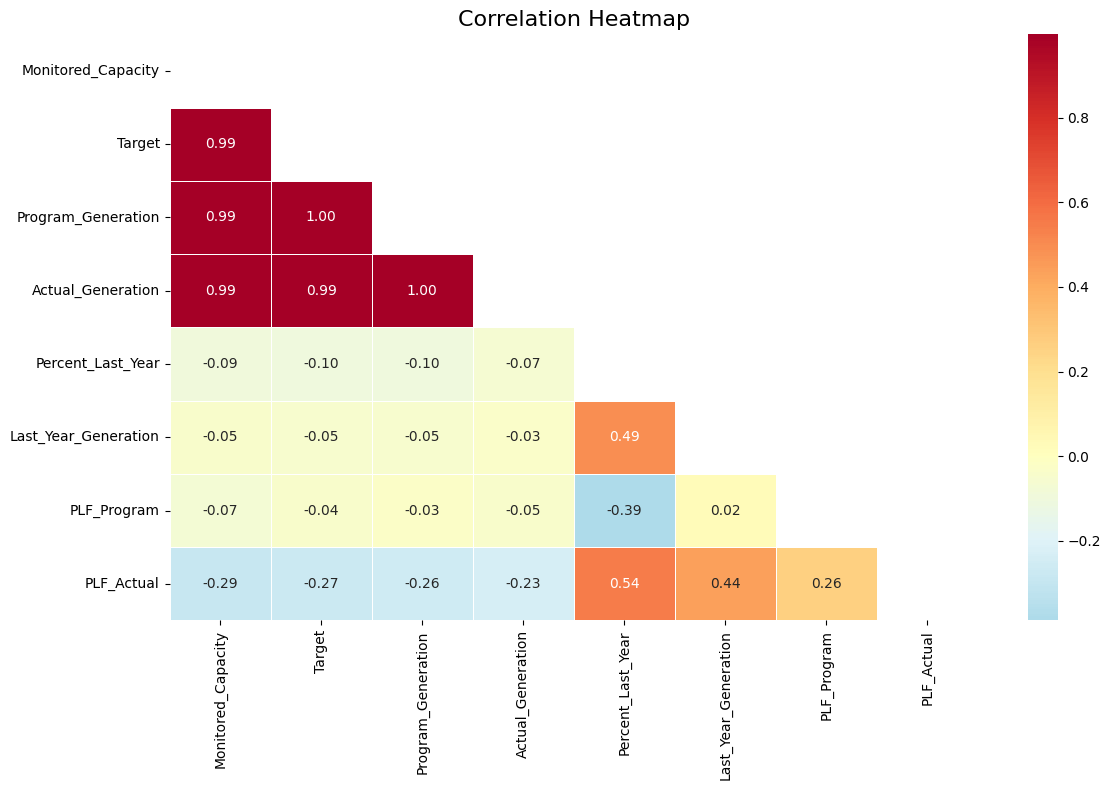

In [32]:
# 1. CORRELATION HEATMAP

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    linewidths=0.5,
    center=0
)

plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

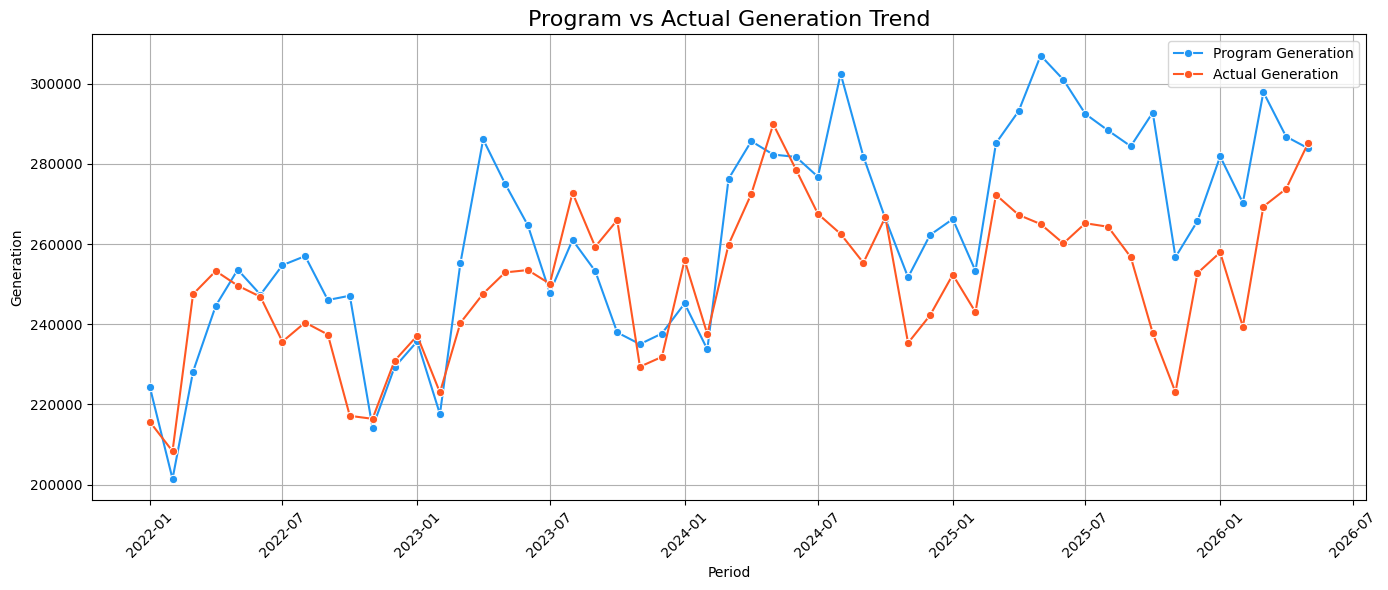

In [33]:
# 2. TREND INTERACTIONS (Program vs Actual Generation Over Time)

monthly_trend = df.groupby('Period')[
    ['Program_Generation', 'Actual_Generation']
].sum().reset_index()

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_trend,
    x='Period',
    y='Program_Generation',
    label='Program Generation',
    marker='o'
)

sns.lineplot(
    data=monthly_trend,
    x='Period',
    y='Actual_Generation',
    label='Actual Generation',
    marker='o'
)

plt.title('Program vs Actual Generation Trend', fontsize=16)
plt.xlabel('Period')
plt.ylabel('Generation')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

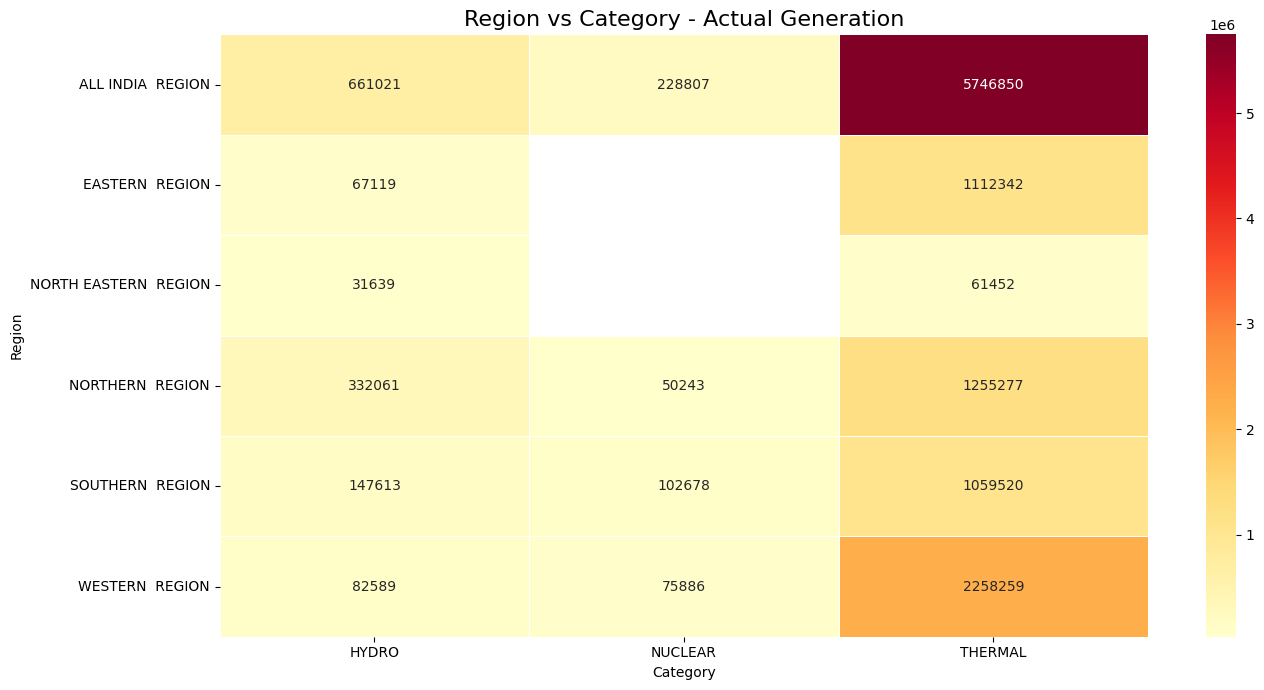

In [34]:
# 3. REGION + CATEGORY ANALYSIS
region_category = df.pivot_table(
    values='Actual_Generation',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    region_category,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Region vs Category - Actual Generation', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

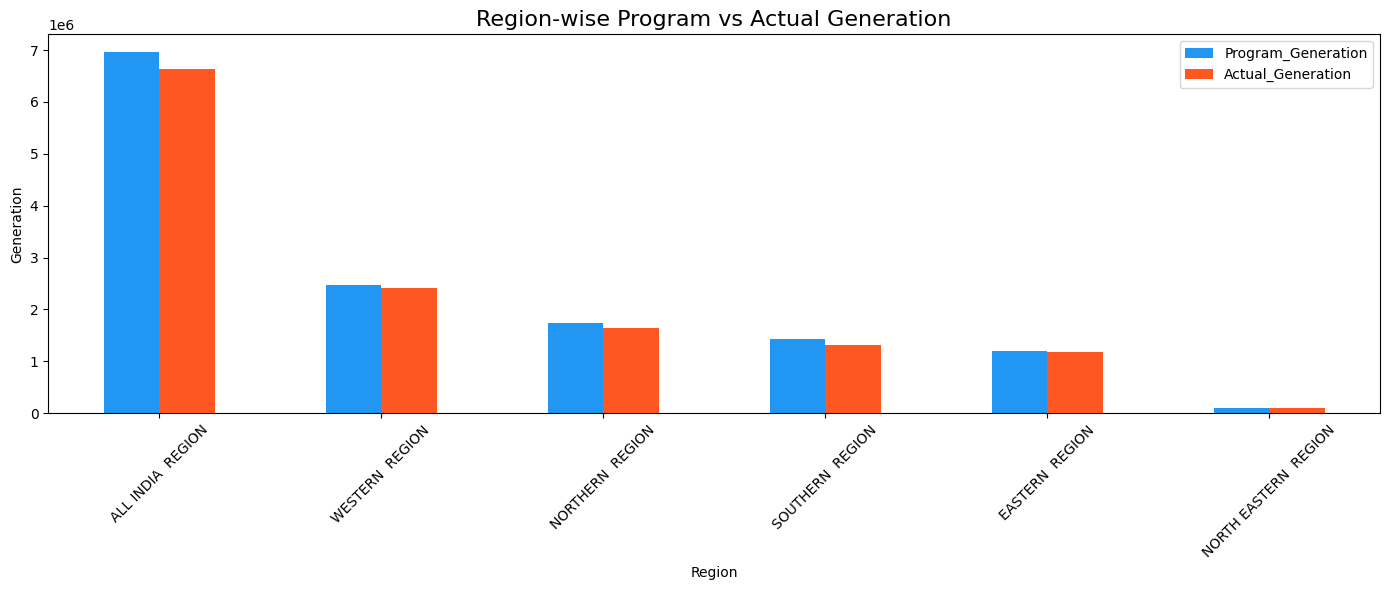

In [35]:
# 4. REGION-WISE GENERATION COMPARISON
region_generation = df.groupby('Region')[
    ['Program_Generation', 'Actual_Generation']
].sum().sort_values(by='Actual_Generation', ascending=False)

region_generation.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Region-wise Program vs Actual Generation', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Generation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

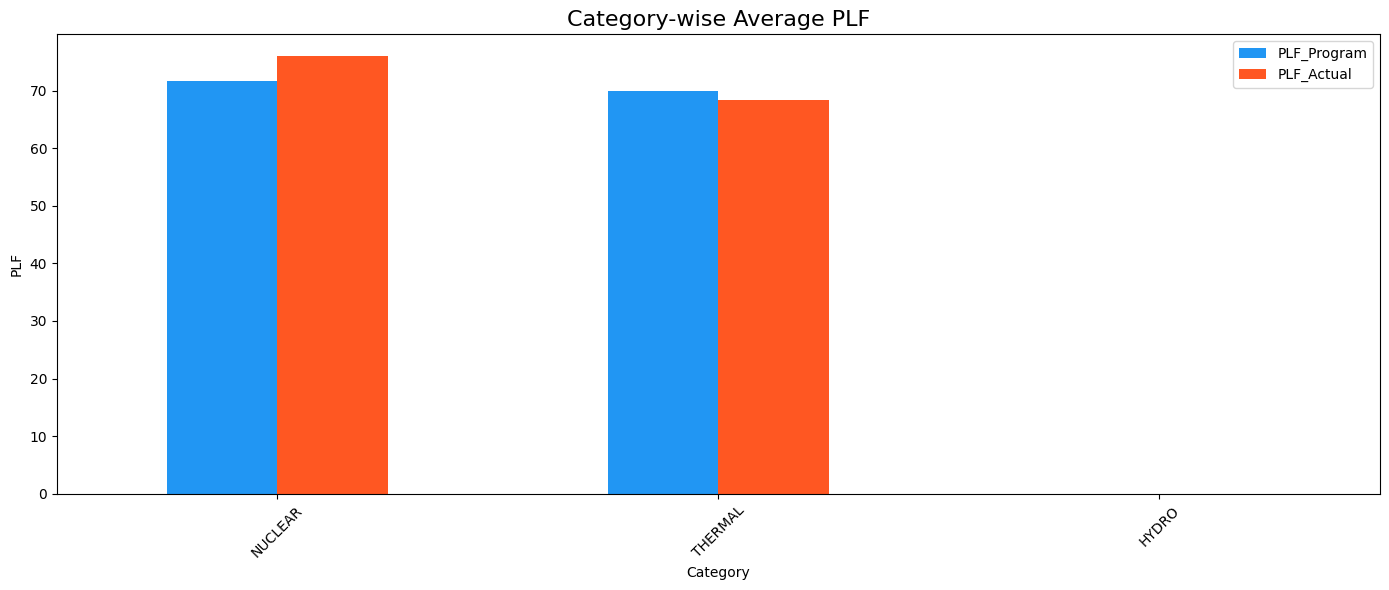

In [36]:
# 5. CATEGORY-WISE PLF ANALYSIS
category_plf = df.groupby('Category')[
    ['PLF_Program', 'PLF_Actual']
].mean().sort_values(by='PLF_Actual', ascending=False)

category_plf.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Category-wise Average PLF', fontsize=16)
plt.xlabel('Category')
plt.ylabel('PLF')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

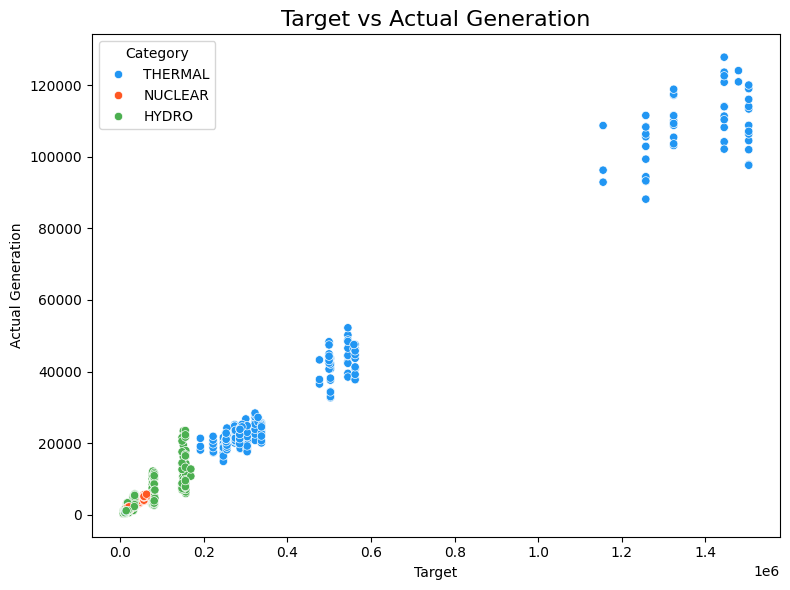

In [37]:
# 6. SCATTERPLOT - TARGET vs ACTUAL
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Target',
    y='Actual_Generation',
    hue='Category'
)

plt.title('Target vs Actual Generation', fontsize=16)
plt.xlabel('Target')
plt.ylabel('Actual Generation')
plt.tight_layout()
plt.show()

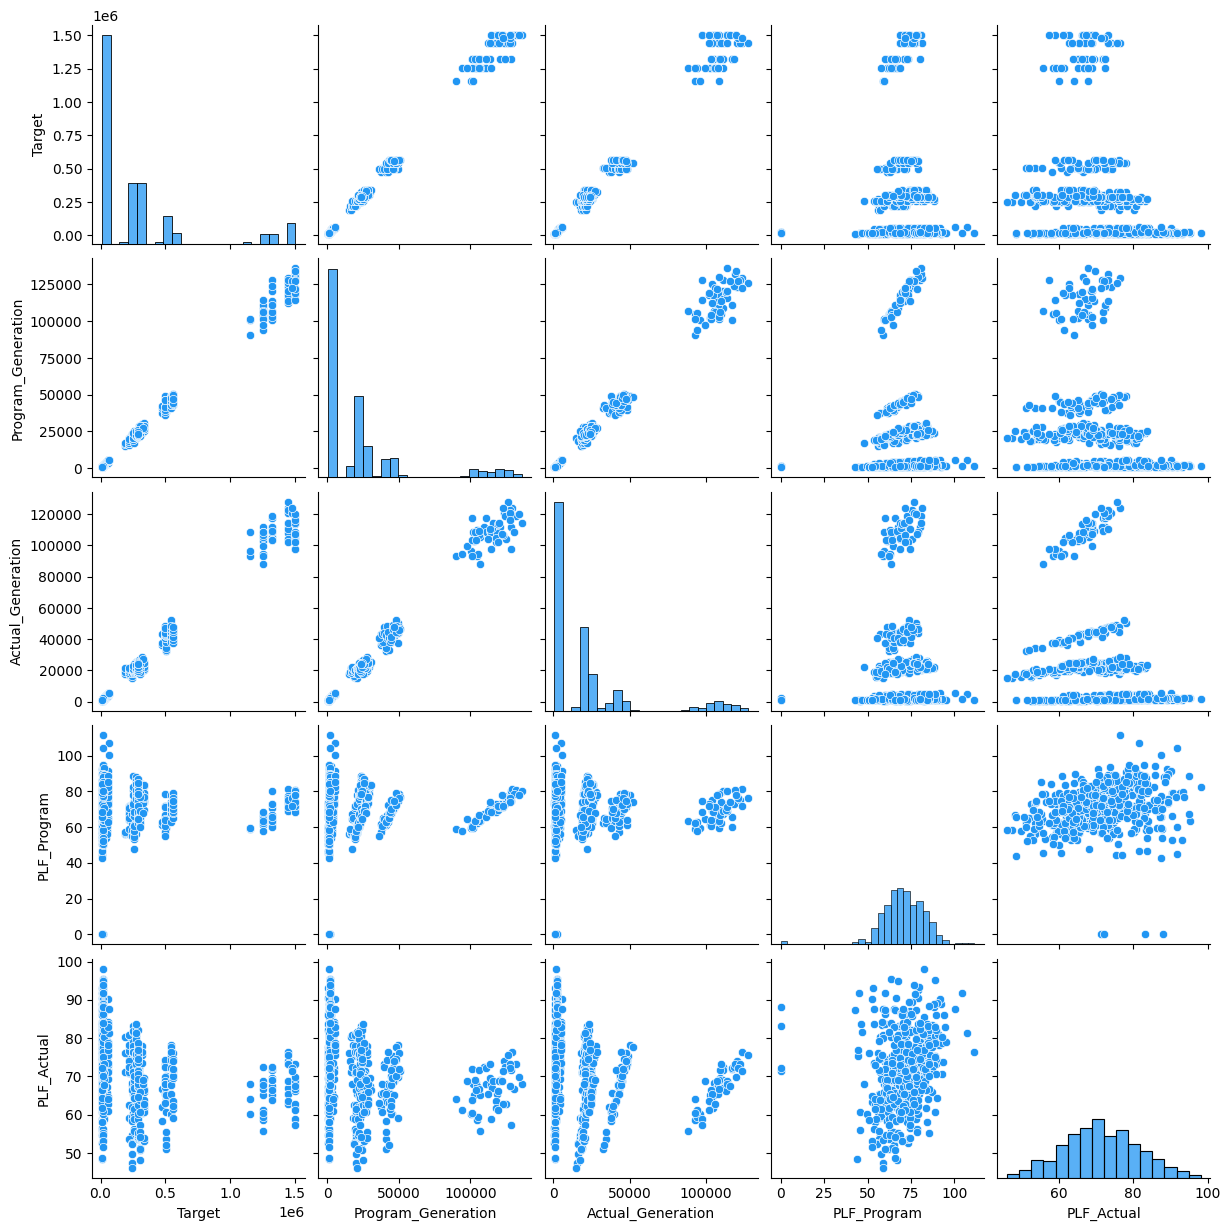

In [38]:
# 7. PAIRPLOT FOR MULTIVARIATE RELATIONSHIPS
pairplot_cols = [
    'Target',
    'Program_Generation',
    'Actual_Generation',
    'PLF_Program',
    'PLF_Actual'
]

sns.pairplot(
    df[pairplot_cols].dropna()
)

plt.show()

### Step 8: Seasonal Decomposition

Seasonal Decomposition was performed to separate the time series into its underlying components: Trend, Seasonality, and Residuals. This analysis helps identify long-term growth patterns, recurring seasonal fluctuations, and irregular variations in power generation over time.

In [39]:
df = df.sort_values('Period')
# Convert generation column to numeric
df['Actual_Generation'] = pd.to_numeric(
    df['Actual_Generation'],
    errors='coerce'
)

In [40]:
# CREATE TIME SERIES
# Monthly total generation
ts = df.groupby('Period')['Actual_Generation'].sum()
# If monthly data exists but dates are irregular
ts = ts.asfreq('MS')
# Fill missing values
ts = ts.fillna(method='ffill')

In [41]:
# SEASONAL DECOMPOSITION

# period=12 for monthly seasonality
decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=12
)
# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

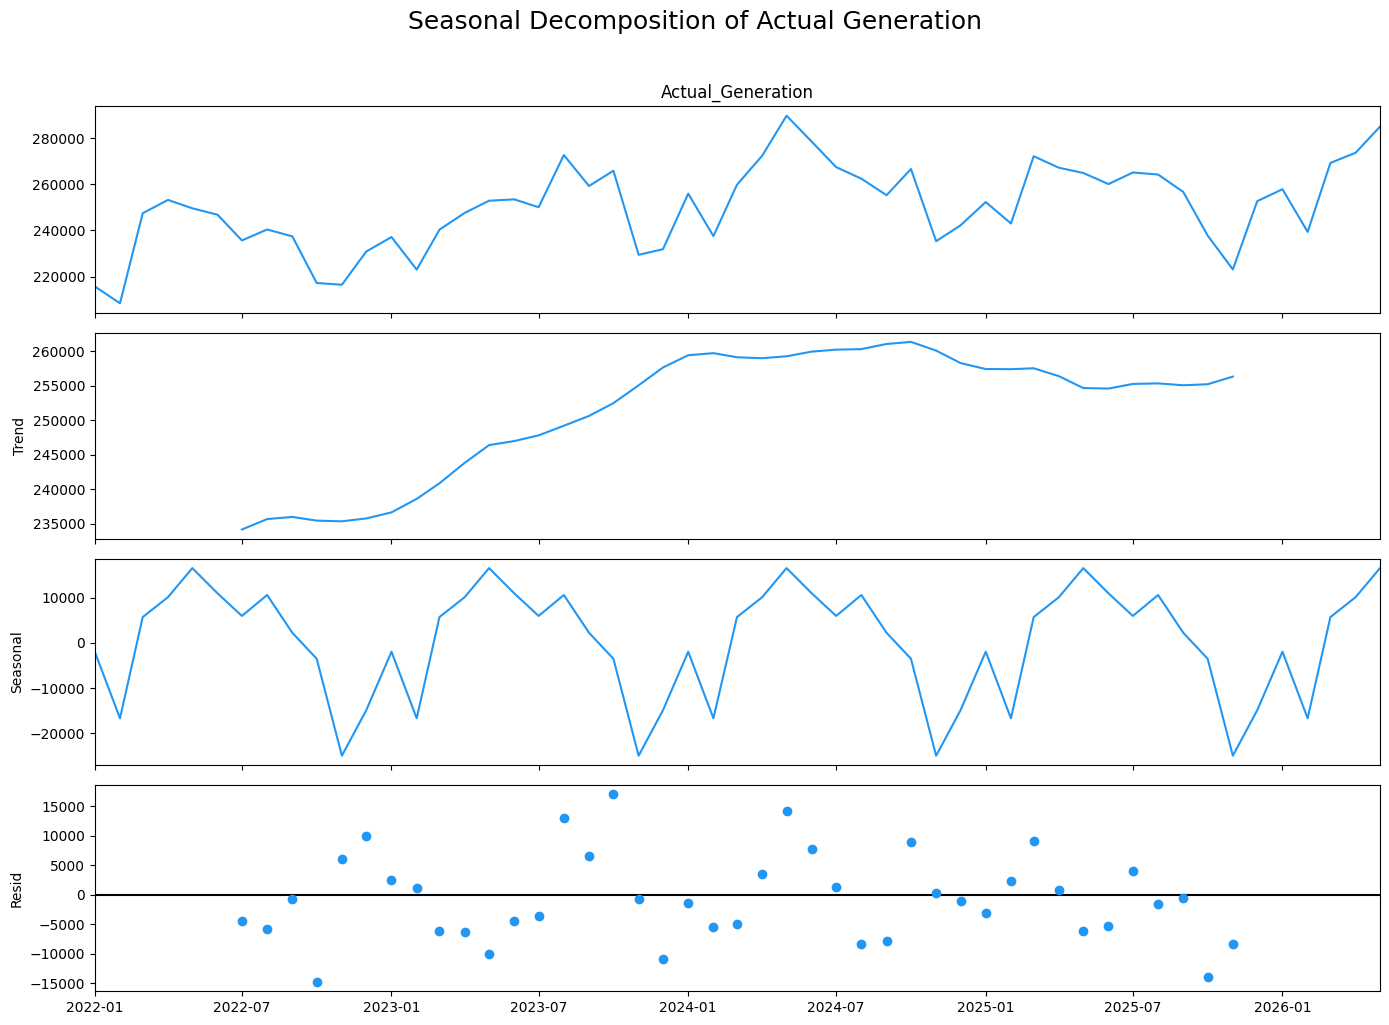

In [42]:
# PLOT COMPLETE DECOMPOSITION
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle(
    'Seasonal Decomposition of Actual Generation',
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

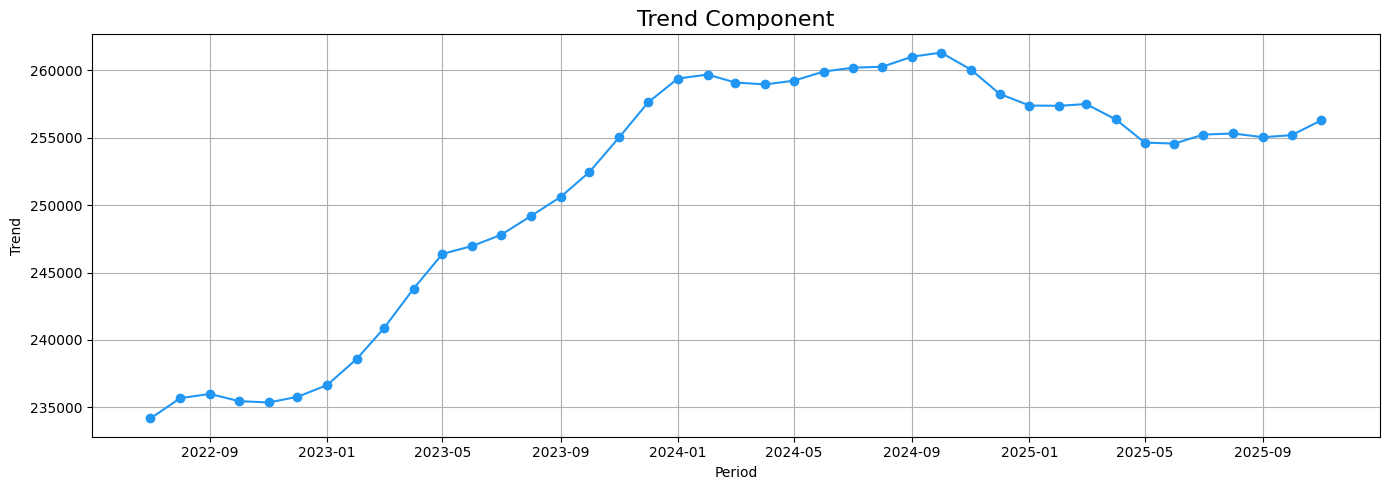

In [43]:
# TREND ANALYSIS
plt.figure(figsize=(14, 5))

plt.plot(
    trend,
    marker='o'
)

plt.title('Trend Component', fontsize=16)
plt.xlabel('Period')
plt.ylabel('Trend')
plt.grid(True)

plt.tight_layout()
plt.show()

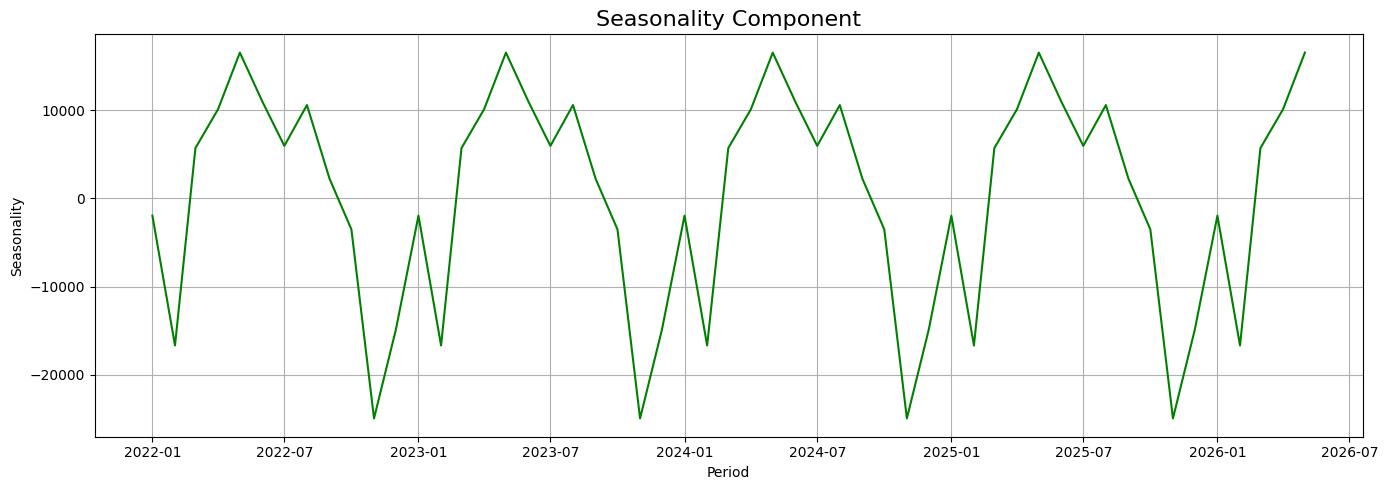

In [44]:
# SEASONALITY ANALYSIS
plt.figure(figsize=(14, 5))
plt.plot(
    seasonal,
    color='green'
)
plt.title('Seasonality Component', fontsize=16)
plt.xlabel('Period')
plt.ylabel('Seasonality')
plt.grid(True)
plt.tight_layout()
plt.show()

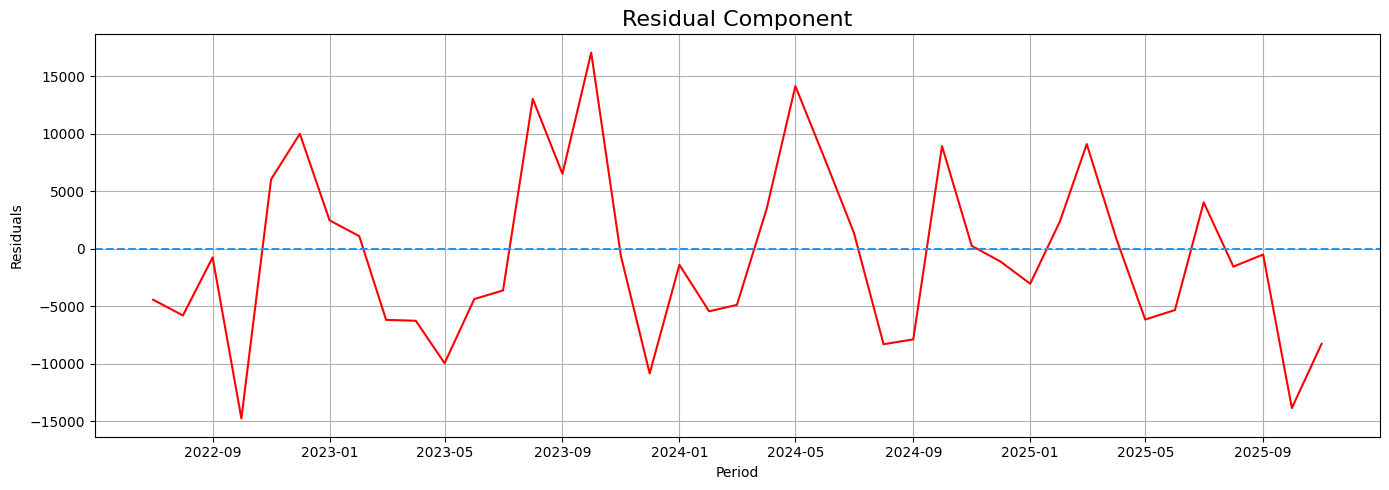

In [45]:
# RESIDUAL ANALYSIS
plt.figure(figsize=(14, 5))
plt.plot(
    residual,
    color='red'
)
plt.axhline(
    y=0,
    linestyle='--'
)
plt.title('Residual Component', fontsize=16)
plt.xlabel('Period')
plt.ylabel('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

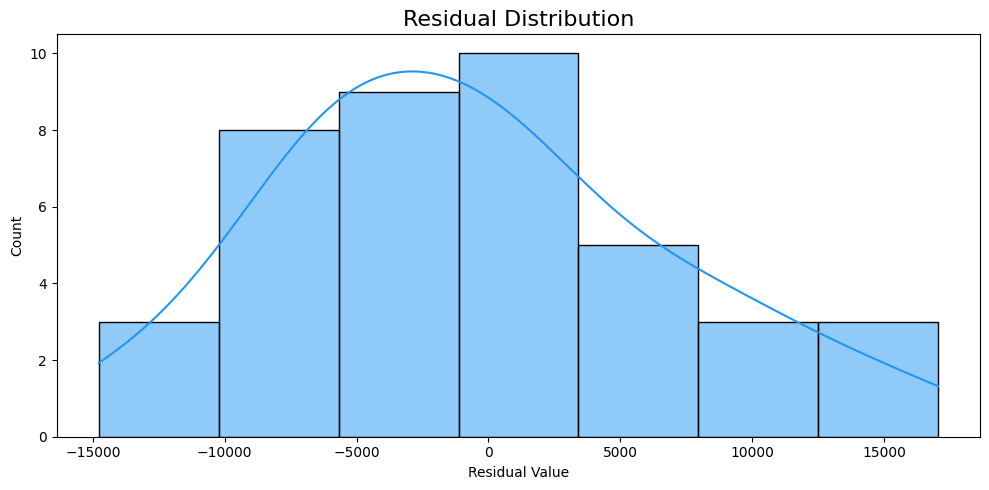

In [46]:
# RESIDUAL DISTRIBUTION
plt.figure(figsize=(10, 5))
sns.histplot(
    residual.dropna(),
    kde=True
)
plt.title('Residual Distribution', fontsize=16)
plt.xlabel('Residual Value')
plt.tight_layout()
plt.show()

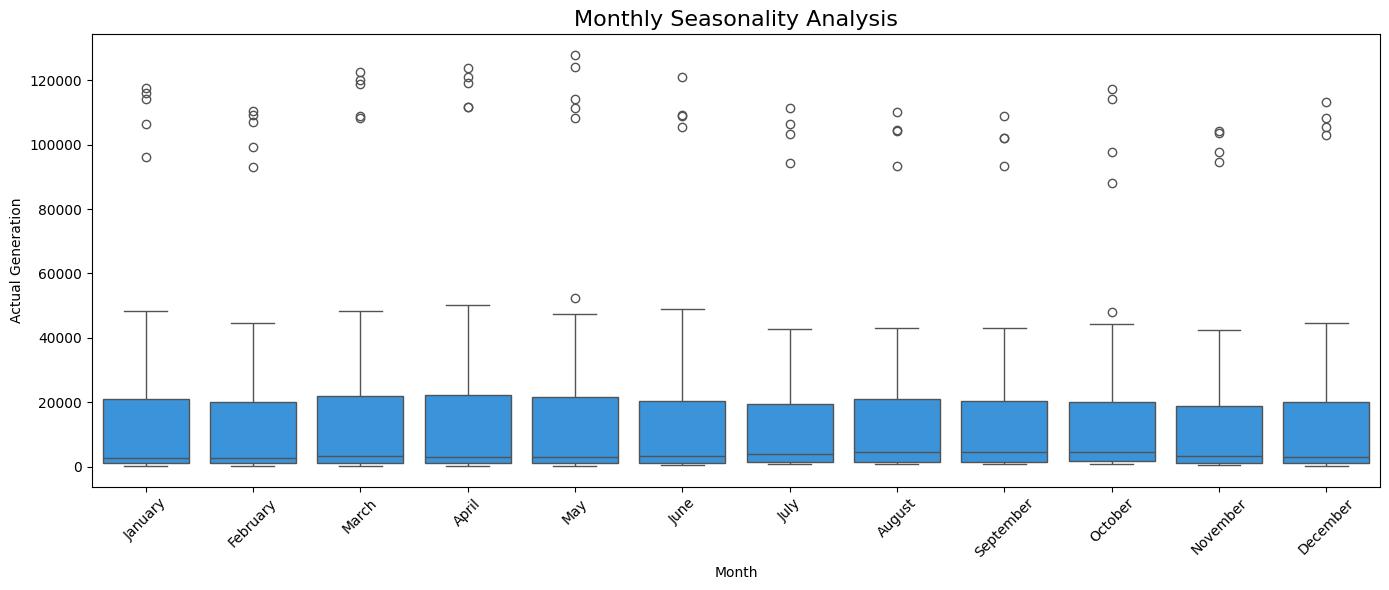

In [47]:
# BOXPLOT FOR SEASONALITY BY MONTH
season_df = df.copy()
season_df['Month'] = season_df['Period'].dt.month_name()

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=season_df,
    x='Month',
    y='Actual_Generation'
)

plt.title('Monthly Seasonality Analysis', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Actual Generation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 9: Region-wise Analysis

Region-wise Analysis was conducted to compare power generation performance across different regions of India. The analysis examines variations in generation levels, capacity utilization, and contribution of each region to the overall power generation output.

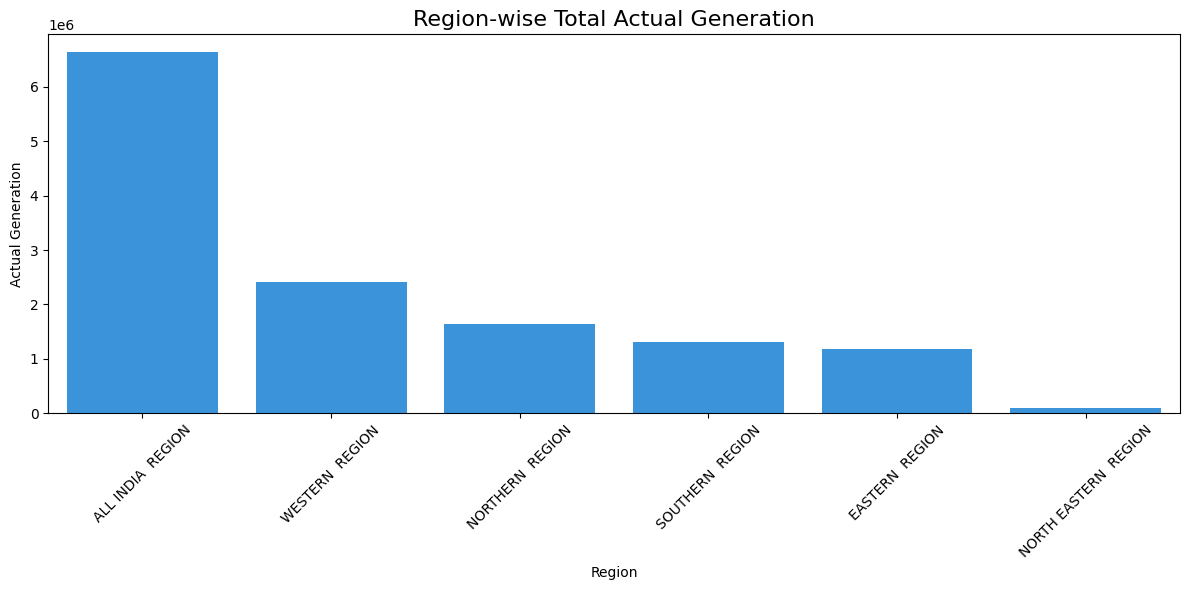

In [48]:
# 1. REGION-WISE TOTAL ACTUAL GENERATION
region_actual = (
    df.groupby('Region')['Actual_Generation']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=region_actual.index,
    y=region_actual.values
)

plt.title('Region-wise Total Actual Generation', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Actual Generation')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

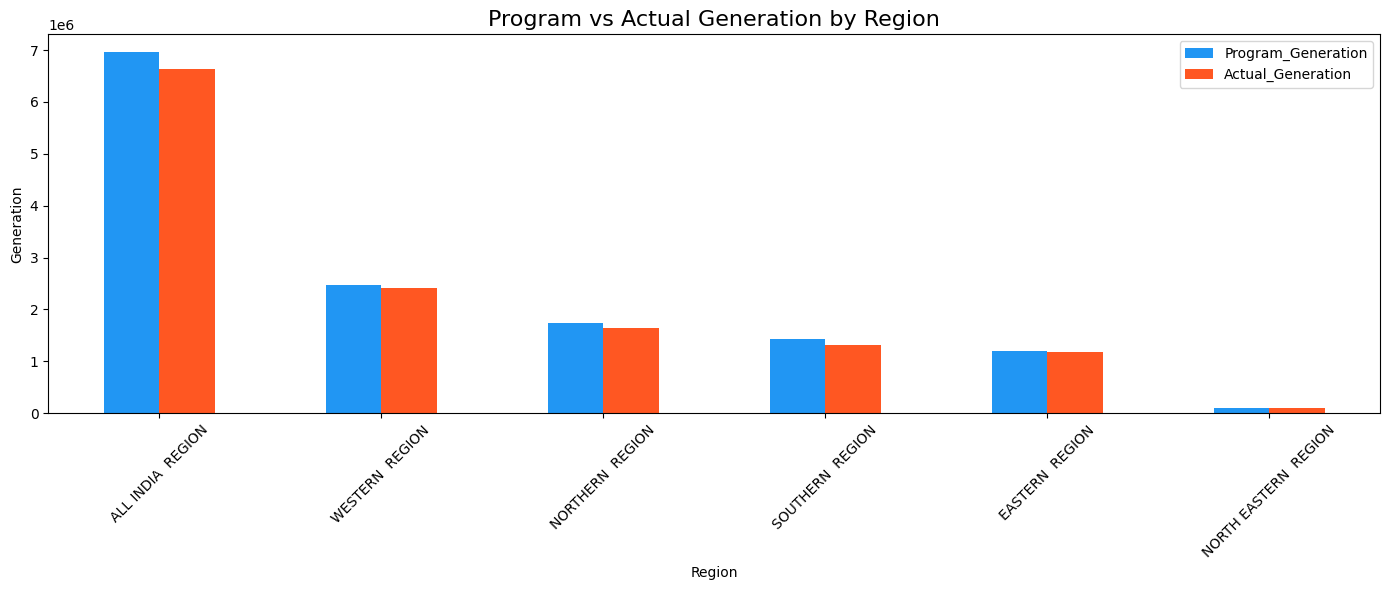

In [49]:
# 2. REGION-WISE PROGRAM vs ACTUAL

region_compare = (
    df.groupby('Region')[
        ['Program_Generation', 'Actual_Generation']
    ]
    .sum()
    .sort_values(by='Actual_Generation', ascending=False)
)

region_compare.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Program vs Actual Generation by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Generation')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

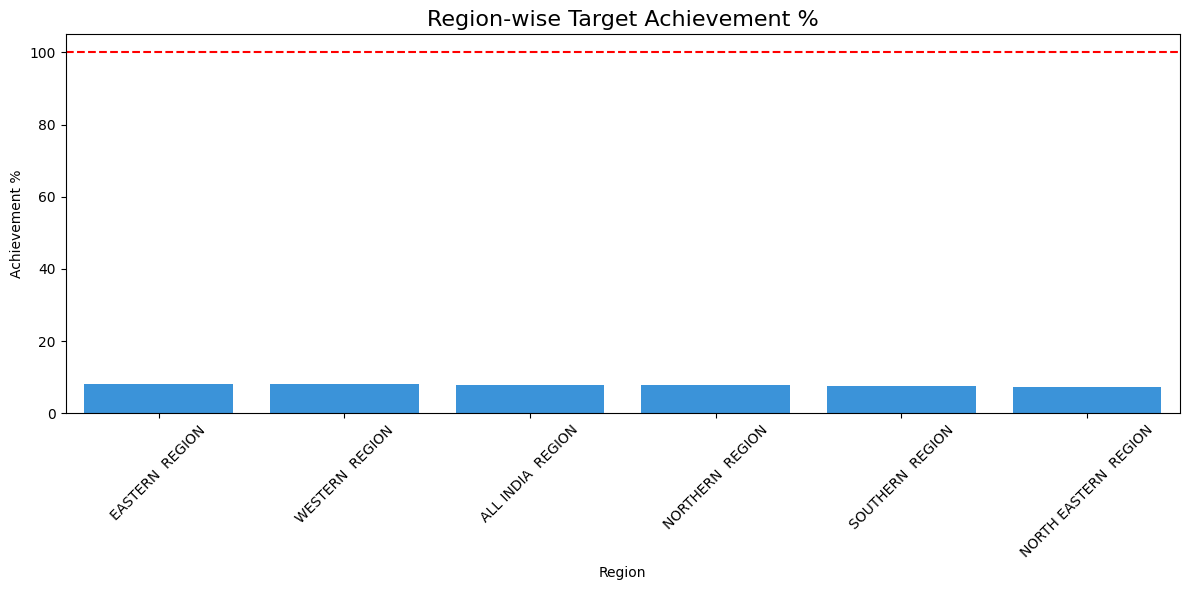

In [50]:
# 3. REGION-WISE TARGET ACHIEVEMENT
region_target = df.groupby('Region')[
    ['Target', 'Actual_Generation']
].sum()

region_target['Achievement_%'] = (
    region_target['Actual_Generation']
    / region_target['Target']
) * 100

region_target = region_target.sort_values(
    by='Achievement_%',
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=region_target.index,
    y=region_target['Achievement_%']
)

plt.axhline(
    y=100,
    linestyle='--',
    color='red'
)

plt.title('Region-wise Target Achievement %', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Achievement %')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

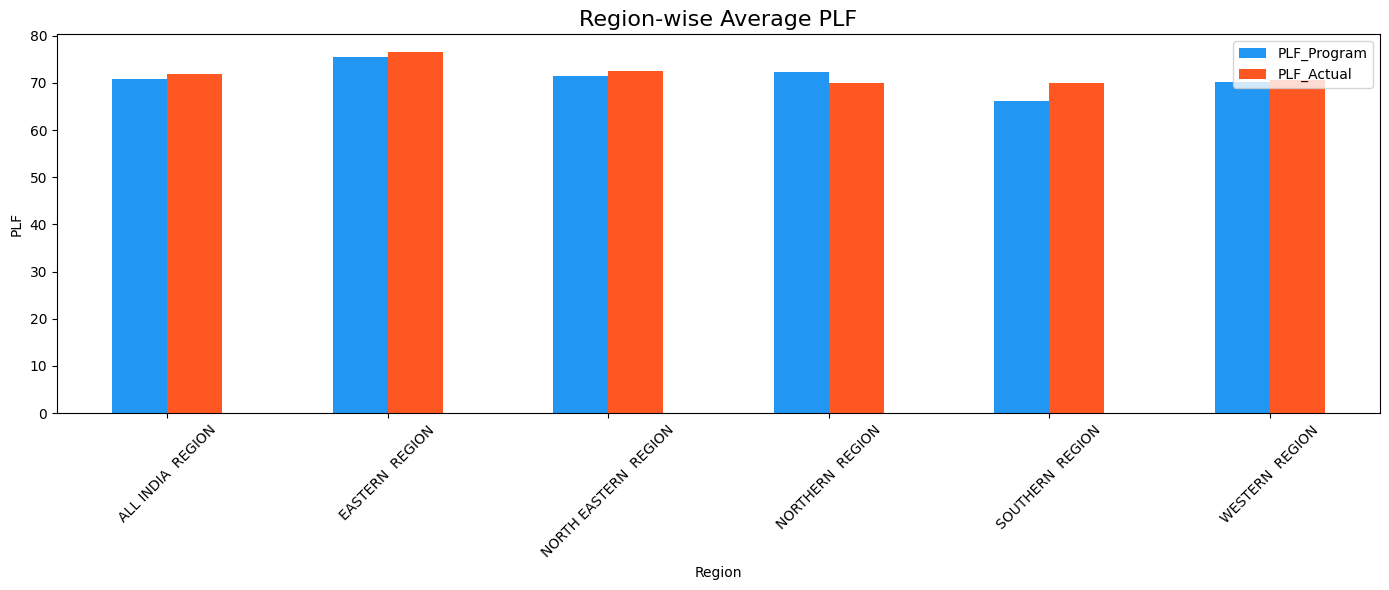

In [51]:
# 4. REGION-WISE PLF ANALYSIS
region_plf = df.groupby('Region')[
    ['PLF_Program', 'PLF_Actual']
].mean()

region_plf.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Region-wise Average PLF', fontsize=16)
plt.xlabel('Region')
plt.ylabel('PLF')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

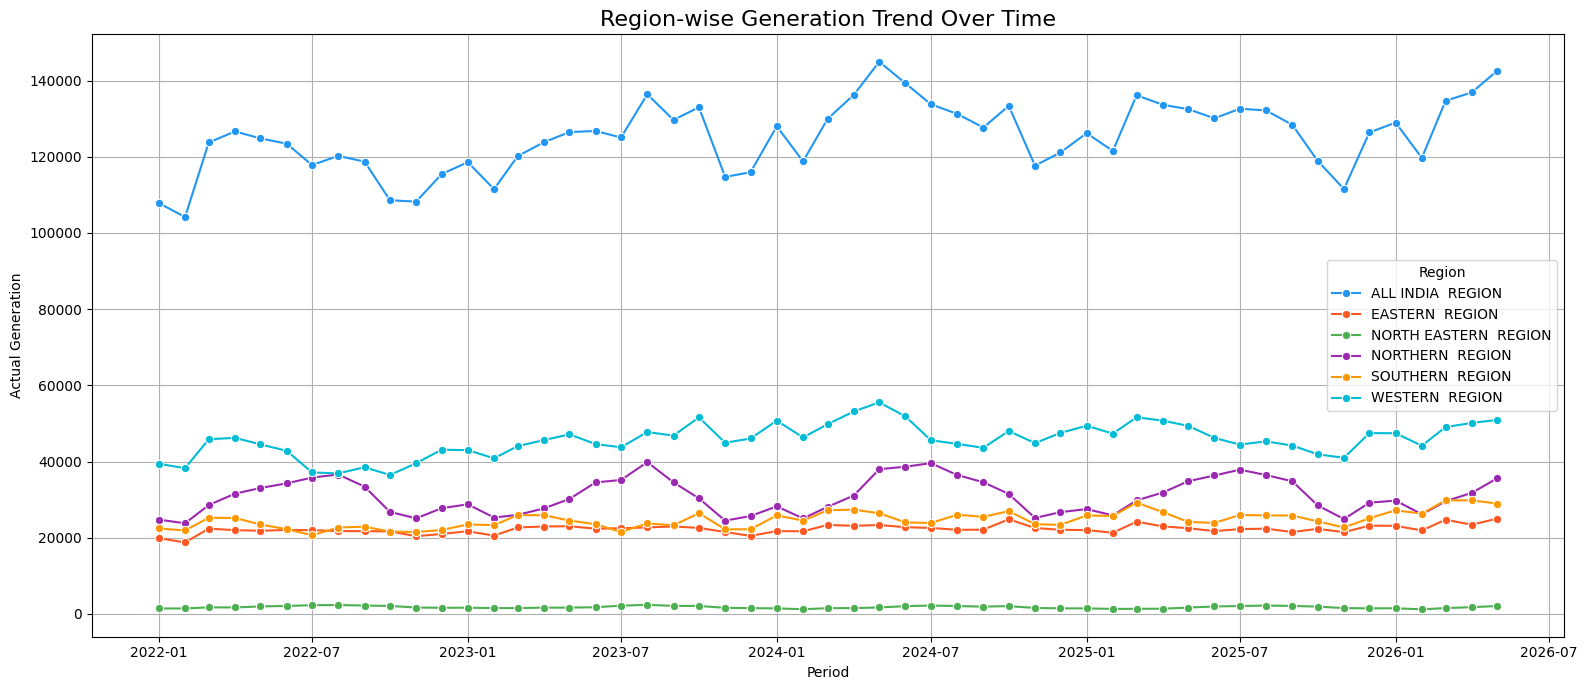

In [52]:
# 5. REGION-WISE TREND ANALYSIS
region_trend = (
    df.groupby(['Period', 'Region'])['Actual_Generation']
    .sum()
    .reset_index()
)

plt.figure(figsize=(16, 7))

sns.lineplot(
    data=region_trend,
    x='Period',
    y='Actual_Generation',
    hue='Region',
    marker='o'
)

plt.title('Region-wise Generation Trend Over Time', fontsize=16)
plt.xlabel('Period')
plt.ylabel('Actual Generation')

plt.grid(True)

plt.tight_layout()
plt.show()


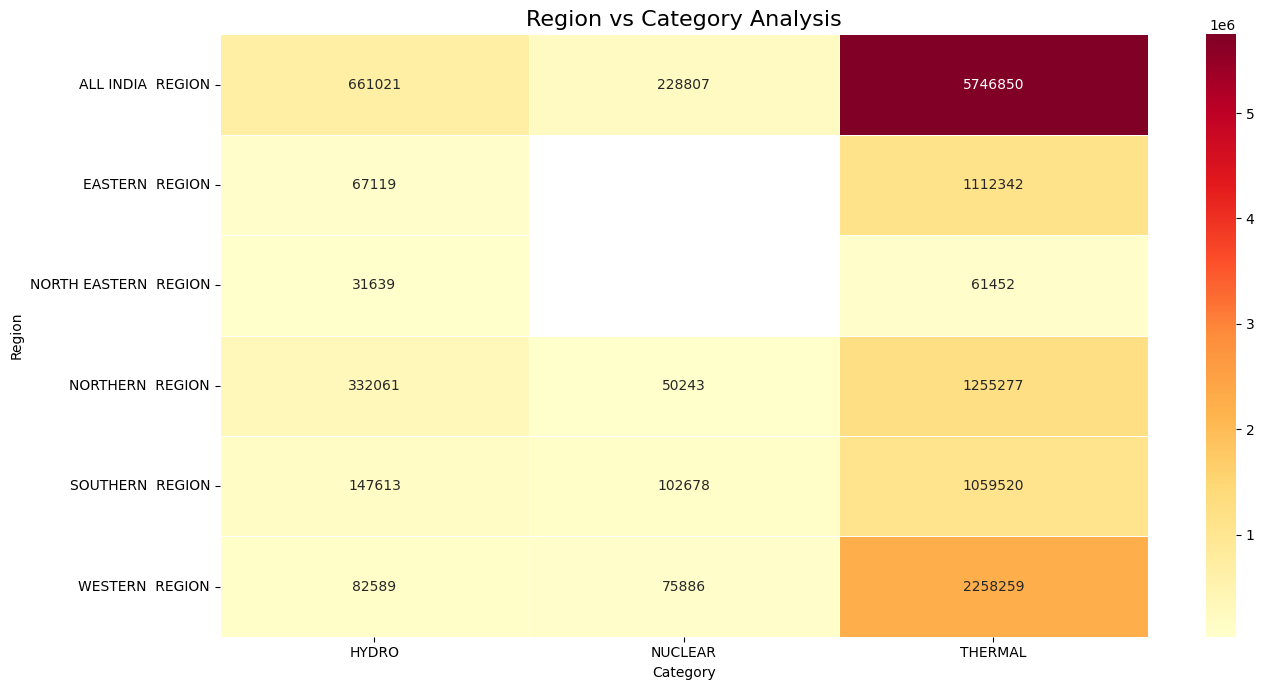

In [53]:
# 6. REGION vs CATEGORY HEATMAP
region_category = df.pivot_table(
    values='Actual_Generation',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    region_category,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Region vs Category Analysis', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

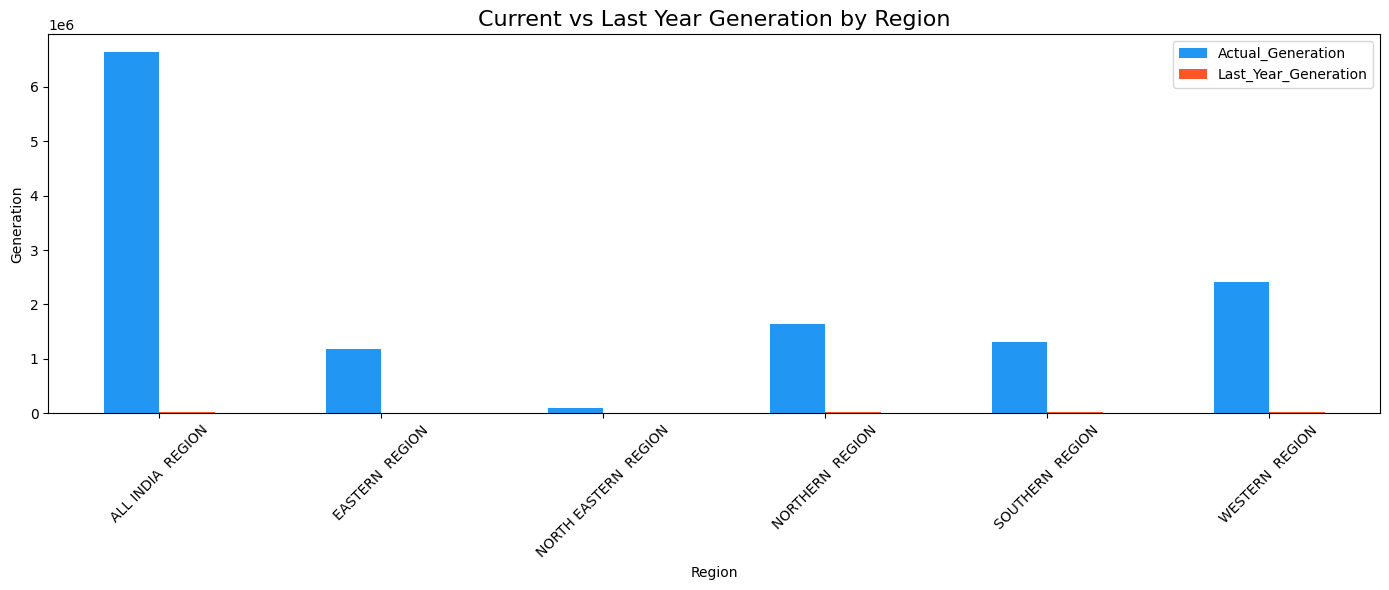

In [54]:
# 7. REGION-WISE YOY PERFORMANCE
region_yoy = df.groupby('Region')[
    ['Actual_Generation', 'Last_Year_Generation']
].sum()

region_yoy.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Current vs Last Year Generation by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Generation')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

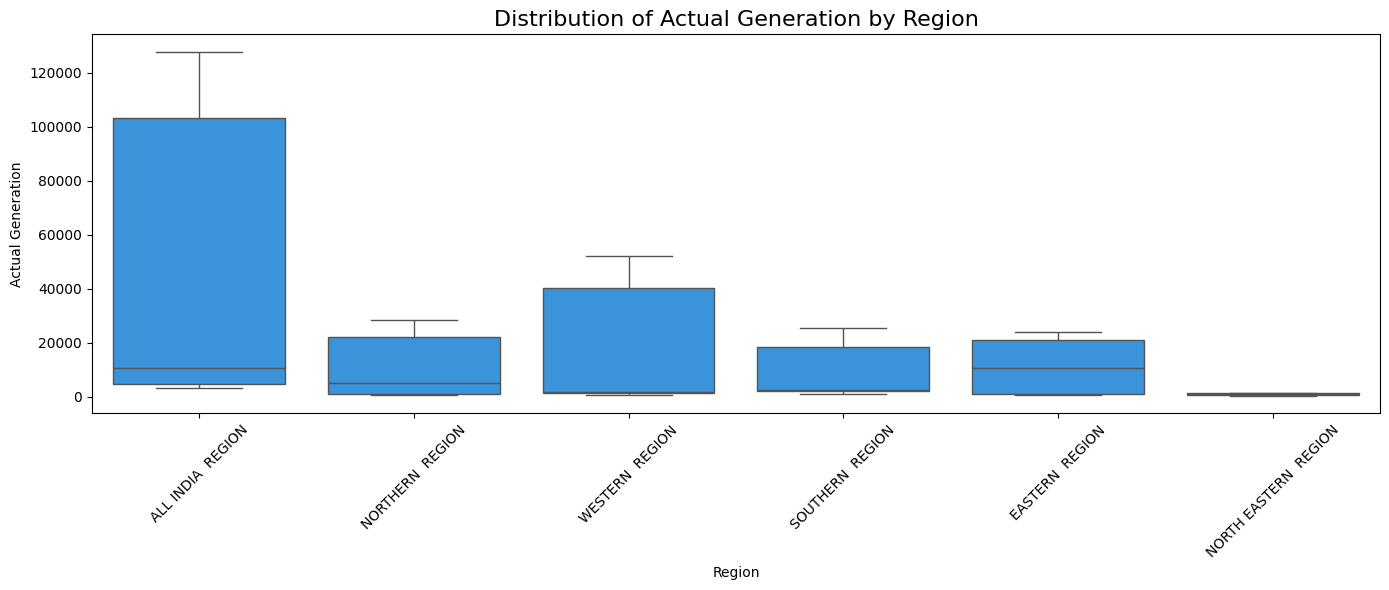

In [55]:
# 8. REGION-WISE DISTRIBUTION
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='Region',
    y='Actual_Generation'
)

plt.title('Distribution of Actual Generation by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Actual Generation')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Step 10: Thermal vs Hydro vs Nuclear Comparison

This analysis compares the performance and contribution of the three major power generation sources: Thermal, Hydro, and Nuclear. The comparison helps identify differences in generation levels, capacity utilization, and overall contribution to India's electricity production.

In [56]:
power_df = df[
    df['Category'].isin(['THERMAL', 'HYDRO', 'NUCLEAR'])
]


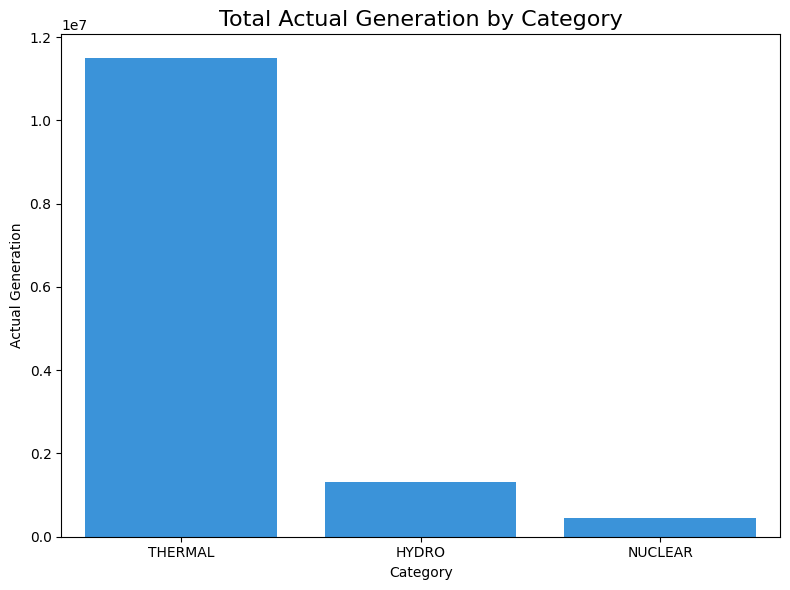

In [57]:
# 1. TOTAL ACTUAL GENERATION COMPARISON
generation_compare = (
    power_df.groupby('Category')['Actual_Generation']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=generation_compare.index,
    y=generation_compare.values
)

plt.title('Total Actual Generation by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Actual Generation')

plt.tight_layout()
plt.show()


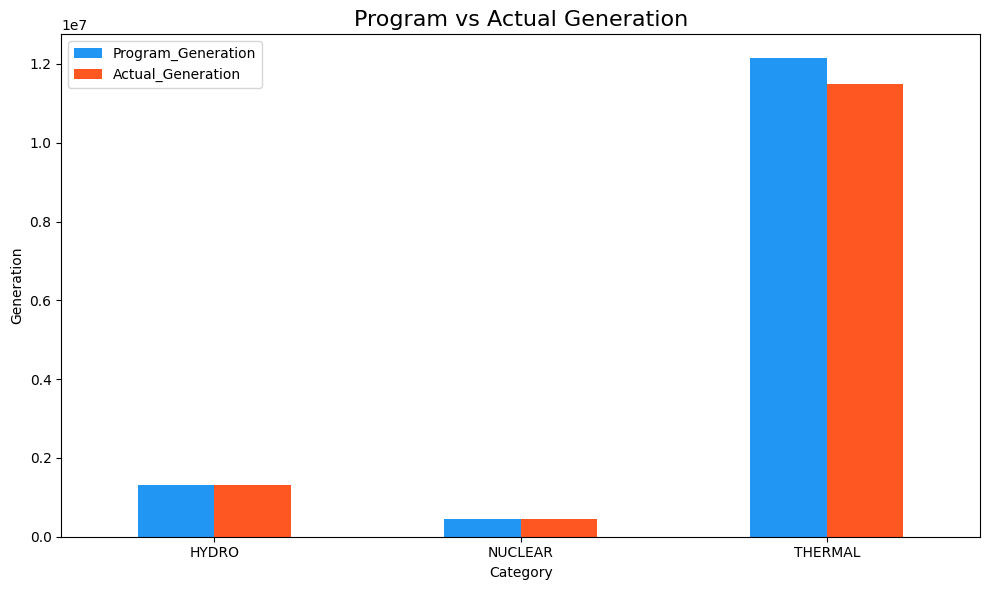

In [58]:
# 2. PROGRAM vs ACTUAL GENERATION
program_actual = (
    power_df.groupby('Category')[
        ['Program_Generation', 'Actual_Generation']
    ]
    .sum()
)

program_actual.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Program vs Actual Generation', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Generation')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

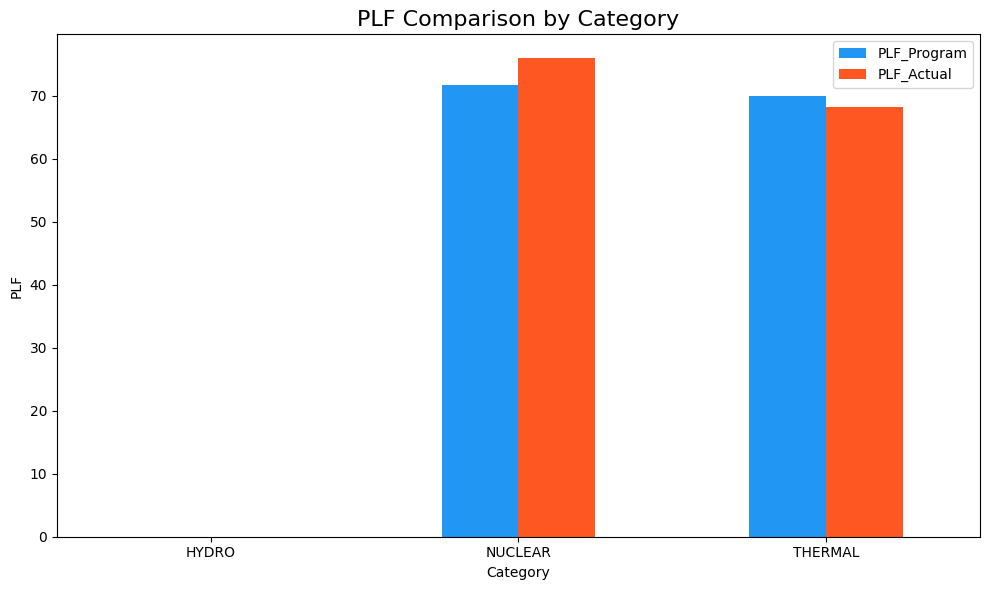

In [59]:
# 3. PLF COMPARISON
plf_compare = (
    power_df.groupby('Category')[
        ['PLF_Program', 'PLF_Actual']
    ]
    .mean()
)

plf_compare.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('PLF Comparison by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('PLF')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


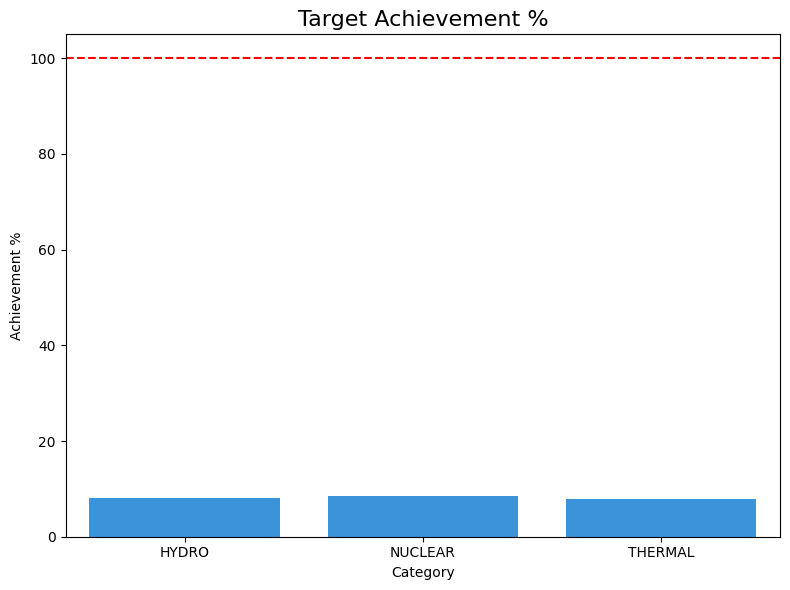

In [60]:
# 4. TARGET ACHIEVEMENT %
achievement = power_df.groupby('Category')[
    ['Target', 'Actual_Generation']
].sum()

achievement['Achievement_%'] = (
    achievement['Actual_Generation']
    / achievement['Target']
) * 100

plt.figure(figsize=(8, 6))

sns.barplot(
    x=achievement.index,
    y=achievement['Achievement_%']
)

plt.axhline(
    y=100,
    linestyle='--',
    color='red'
)

plt.title('Target Achievement %', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Achievement %')

plt.tight_layout()
plt.show()


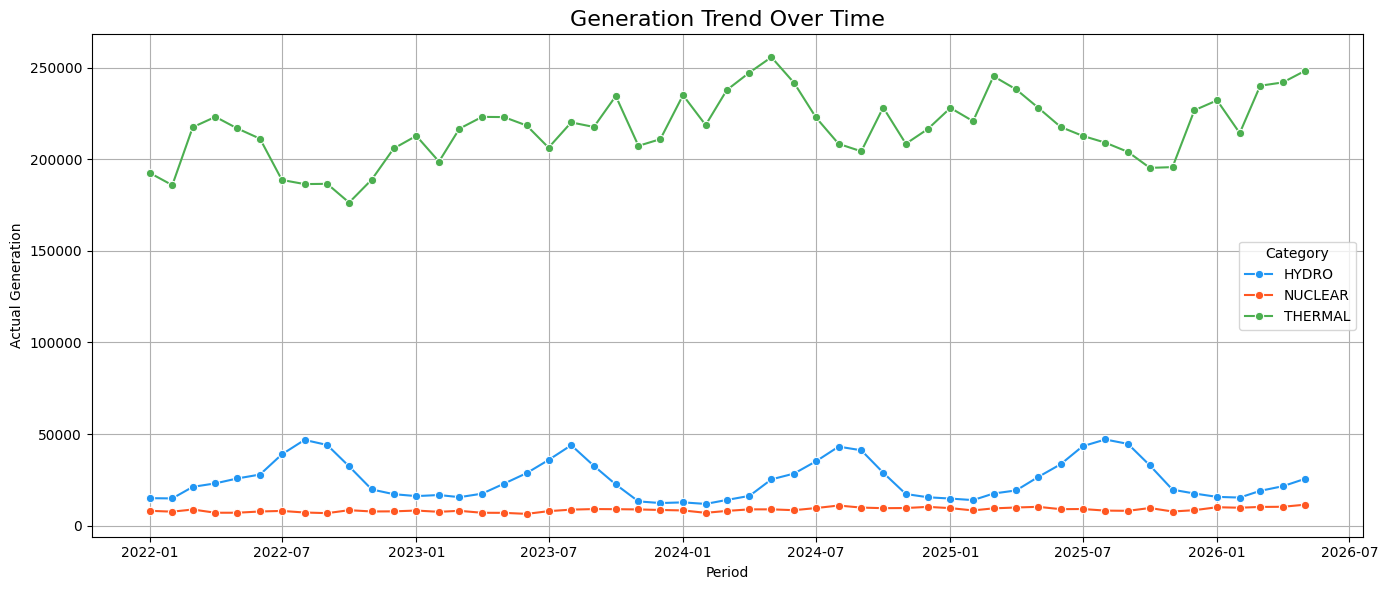

In [61]:
# 5. TREND OVER TIME
trend_df = (
    power_df.groupby(['Period', 'Category'])[
        'Actual_Generation'
    ]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=trend_df,
    x='Period',
    y='Actual_Generation',
    hue='Category',
    marker='o'
)

plt.title('Generation Trend Over Time', fontsize=16)
plt.xlabel('Period')
plt.ylabel('Actual Generation')

plt.grid(True)

plt.tight_layout()
plt.show()

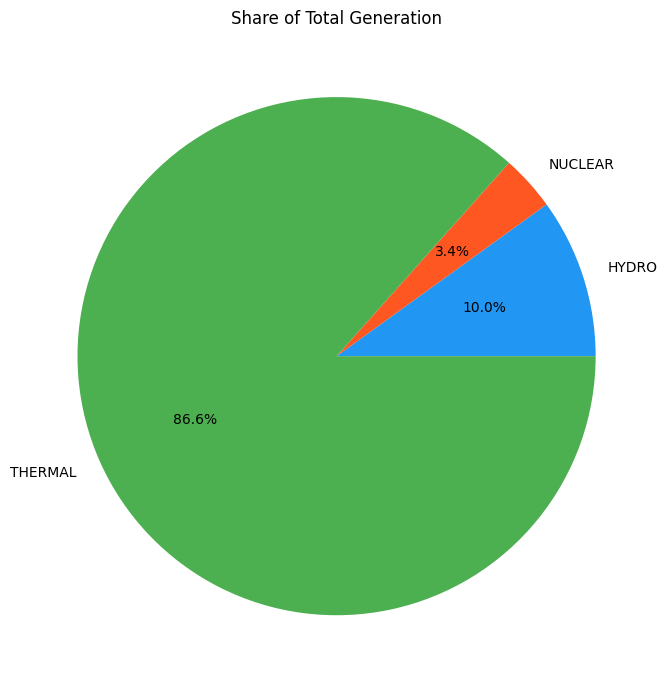

In [62]:
# 6. SHARE OF TOTAL GENERATION
share_df = (
    power_df.groupby('Category')['Actual_Generation']
    .sum()
    .reset_index()
)

plt.figure(figsize=(7, 7))

plt.pie(
    share_df['Actual_Generation'],
    labels=share_df['Category'],
    autopct='%1.1f%%'
)

plt.title('Share of Total Generation')

plt.tight_layout()
plt.show()

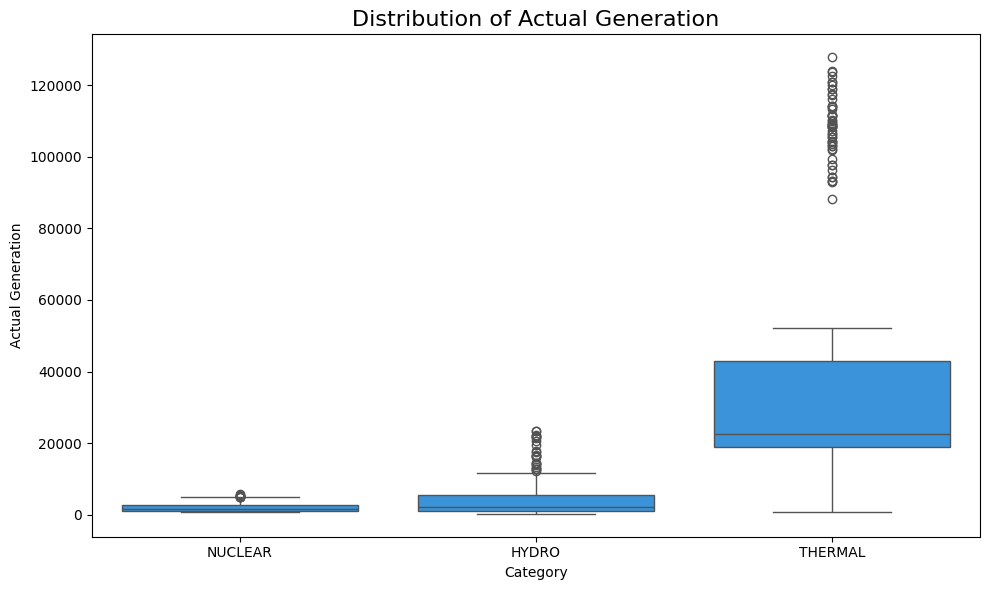

In [63]:
# 7. DISTRIBUTION ANALYSIS
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=power_df,
    x='Category',
    y='Actual_Generation'
)

plt.title('Distribution of Actual Generation', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Actual Generation')

plt.tight_layout()
plt.show()

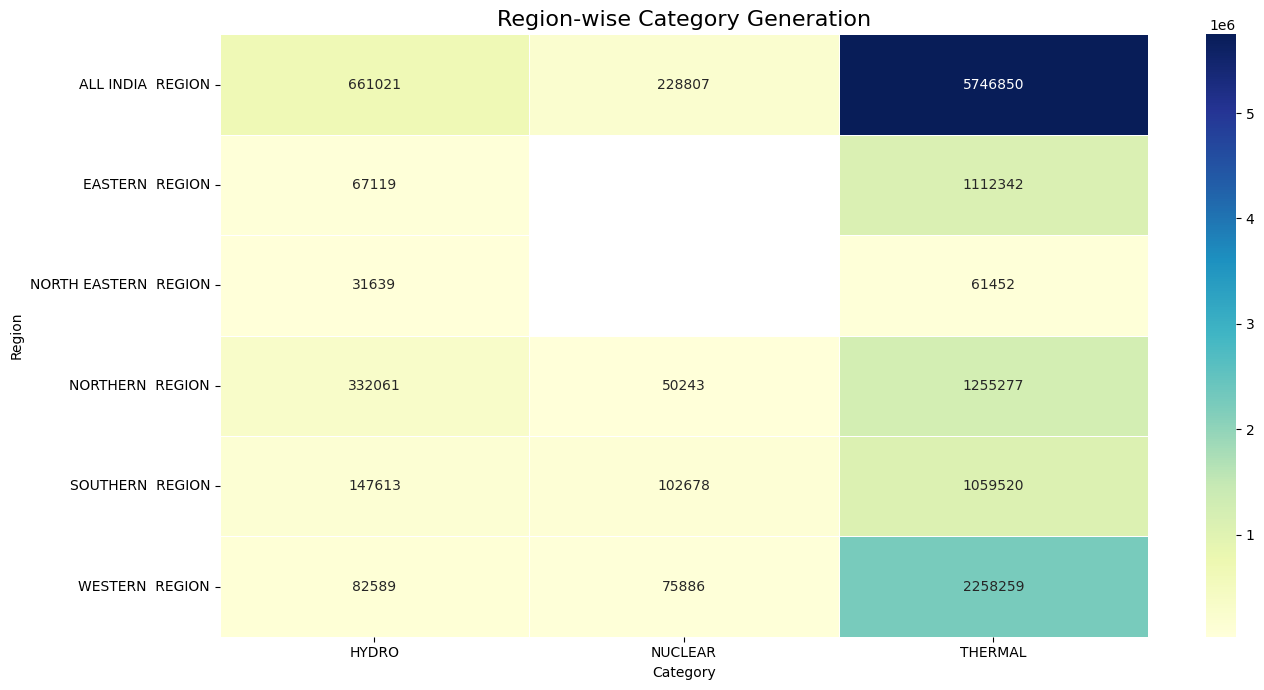

In [64]:
# 8. REGION-WISE CATEGORY ANALYSIS
region_category = power_df.pivot_table(
    values='Actual_Generation',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    region_category,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Region-wise Category Generation', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Region')

plt.tight_layout()
plt.show()


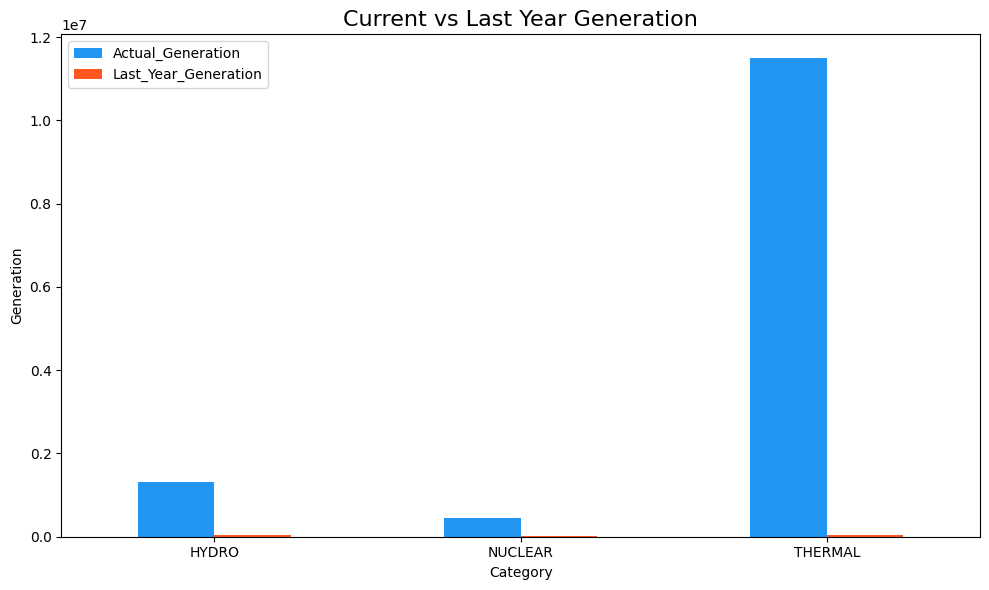

In [65]:
# 9. YEAR-OVER-YEAR COMPARISON
yoy_compare = power_df.groupby('Category')[
    ['Actual_Generation', 'Last_Year_Generation']
].sum()

yoy_compare.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Current vs Last Year Generation', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Generation')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Feature Engineering

Feature engineering was performed to create additional variables that can improve forecasting performance. Time-based features such as Month, Quarter, and Year were extracted from the date column, while lag features, rolling averages, and growth rates were generated from historical generation values. These features help capture temporal trends, seasonality, and past generation patterns within the dataset.

In [66]:
df['Month'] = df['Period'].dt.month
df['Quarter'] = df['Period'].dt.quarter
df['Year'] = df['Period'].dt.year

# LAG FEATURES
df['Lag_1'] = df['Actual_Generation'].shift(1)
df['Lag_2'] = df['Actual_Generation'].shift(2)
df['Lag_3'] = df['Actual_Generation'].shift(3)
df['Lag_12'] = df['Actual_Generation'].shift(12)

In [67]:
# ROLLING AVERAGES
df['Rolling_Mean_3'] = (
    df['Actual_Generation']
    .rolling(window=3)
    .mean()
)

df['Rolling_Mean_6'] = (
    df['Actual_Generation']
    .rolling(window=6)
    .mean()
)

In [68]:
# GROWTH RATE
df['Growth_Rate'] = (
    df['Actual_Generation']
    .pct_change()
) * 100

# Remove null rows after lag creation
df = df.dropna()

In [69]:
# TRAIN TEST SPLIT
# Proper Time-Series Split (NO SHUFFLE)
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [71]:
# FEATURES FOR ML MODELS
features = [
    'Month',
    'Quarter',
    'Year',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_12',
    'Rolling_Mean_3',
    'Rolling_Mean_6',
    'Growth_Rate'
]

target = 'Actual_Generation'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

### Step 12: Model Training and Testing

In this step, forecasting models were trained and evaluated using the prepared dataset. Three models namely SARIMA, Prophet, and XGBoost were implemented to predict future power generation. The dataset was divided into training and testing sets to assess each model's predictive performance and compare their forecasting capabilities.


In [72]:
# 1. SARIMA MODEL
sarima_model = SARIMAX(
    train['Actual_Generation'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

sarima_pred = sarima_result.forecast(
    steps=len(test)
)

d:\Geo\Generation\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\Geo\Generation\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\Geo\Generation\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [73]:
# 2. PROPHET MODEL
prophet_df = df[['Period', 'Actual_Generation']]
prophet_df.columns = ['ds', 'y']
prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]
prophet_model = Prophet()
prophet_model.fit(prophet_train)
future = prophet_test[['ds']]
forecast = prophet_model.predict(future)
prophet_pred = forecast['yhat'].values

00:07:09 - cmdstanpy - INFO - Chain [1] start processing
00:07:10 - cmdstanpy - INFO - Chain [1] done processing


In [74]:
# 3. XGBOOST MODEL
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

### Step 13: Model Evaluation and Comparison

The forecasting models were evaluated using standard performance metrics to measure their prediction accuracy and reliability. The results obtained from SARIMA, Prophet, and XGBoost were compared to identify the model that best captures power generation patterns and provides the most accurate forecasts.

In [77]:
# Evalation Func
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

In [80]:
results = []

results.append(
    evaluate_model(
        y_test,
        sarima_pred,
        'SARIMA'
    )
)

results.append(
    evaluate_model(
        prophet_test['y'],
        prophet_pred,
        'Prophet'
    )
)

results.append(
    evaluate_model(
        y_test,
        xgb_pred,
        'XGBoost'
    )
)

results_df = pd.DataFrame(results)
print("MODEL PERFORMANCE COMPARISON")
print(results_df)


MODEL PERFORMANCE COMPARISON
     Model           MAE          RMSE        MAPE        R2
0   SARIMA  22943.775470  32787.493815  709.554045 -0.014591
1  Prophet  22247.800231  32539.425438  735.402180  0.000704
2  XGBoost   2087.447336   4338.933995   24.359714  0.982232


### Step 14: Understanding Feature Importance - XGBOOST
Feature Importance analysis was performed using the XGBoost model to identify the variables that have the greatest influence on power generation predictions. This helps in understanding which features contribute most to the model's decision-making process and provides insights into the factors affecting power generation.

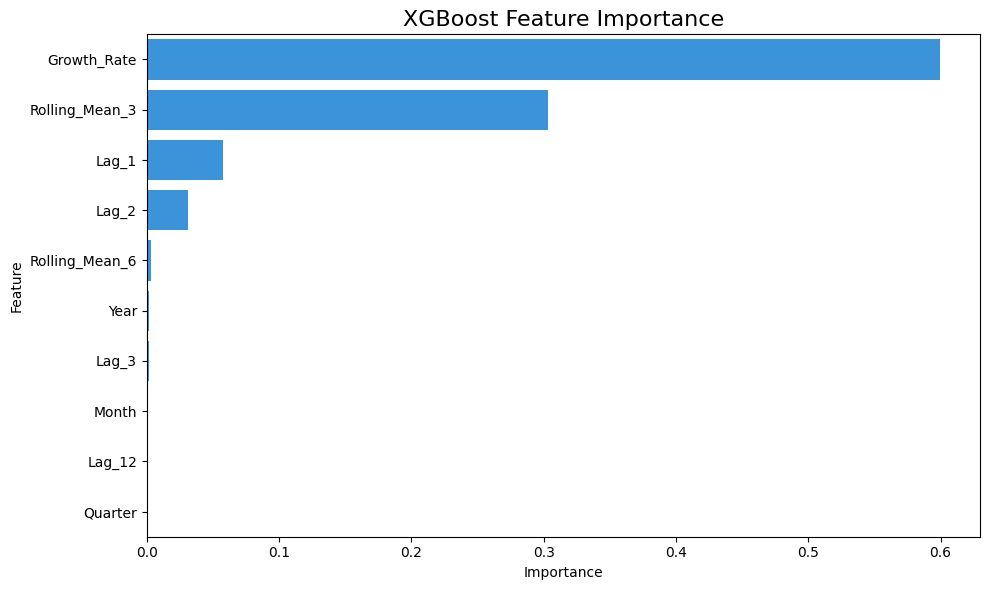

In [81]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title(
    'XGBoost Feature Importance',
    fontsize=16
)

plt.tight_layout()
plt.show()

### Step 15:  Visual Comparison 
Visual comparison was performed to evaluate how closely the predictions from SARIMA, Prophet, and XGBoost align with the actual power generation values. By comparing forecast plots, it becomes easier to assess each model's ability to capture trends, seasonal patterns, and fluctuations in the data.

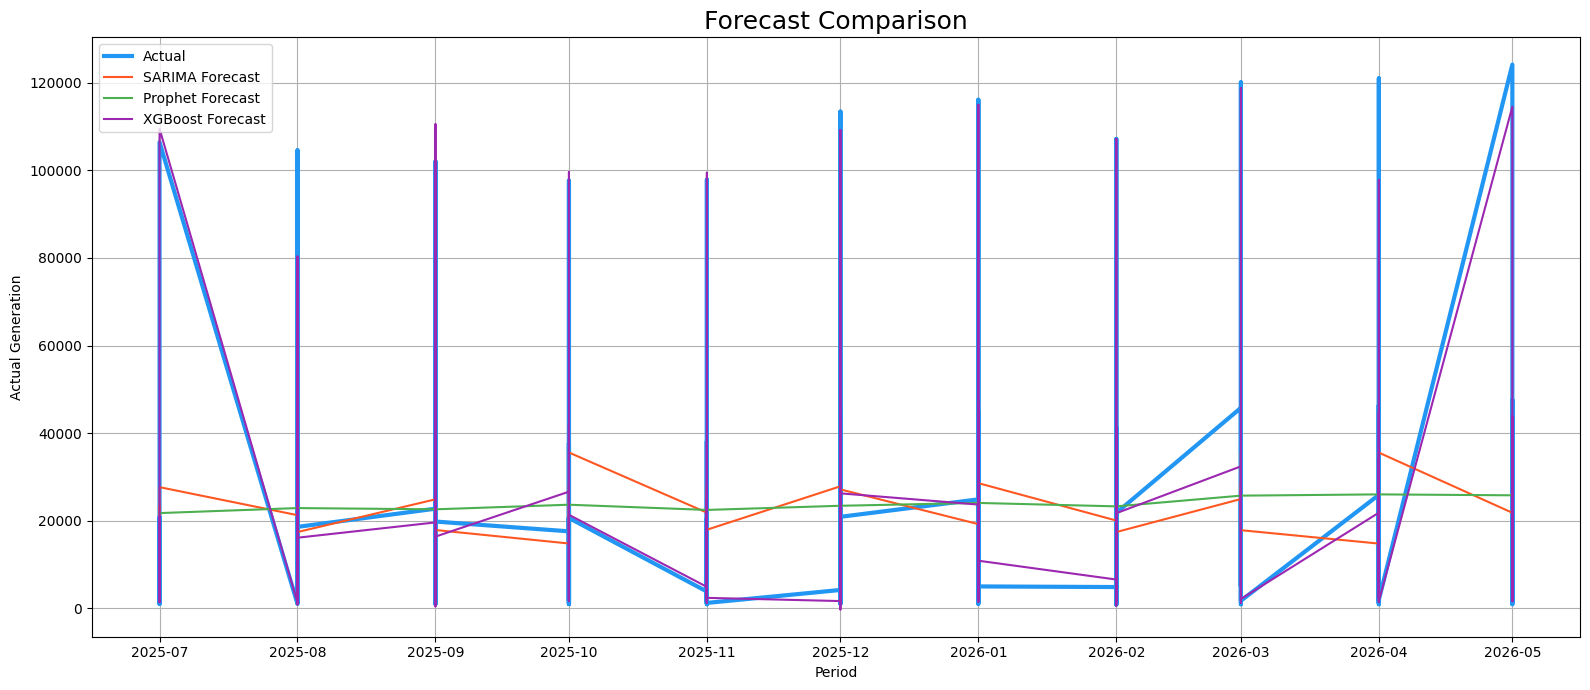

In [83]:
plt.figure(figsize=(16, 7))
# Actual
plt.plot(
    test['Period'],
    y_test,
    label='Actual',
    linewidth=3
)

# SARIMA
plt.plot(
    test['Period'],
    sarima_pred,
    label='SARIMA Forecast'
)

# Prophet
plt.plot(
    prophet_test['ds'],
    prophet_pred,
    label='Prophet Forecast'
)

# XGBoost
plt.plot(
    test['Period'],
    xgb_pred,
    label='XGBoost Forecast'
)

plt.title(
    'Forecast Comparison',
    fontsize=18
)

plt.xlabel('Period')
plt.ylabel('Actual Generation')

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

### Key Findings
- Historical power generation data from January 2022 to May 2026 was successfully collected and consolidated from CEA monthly reports.
- Thermal power contributed the largest share of electricity generation across all regions.
- Seasonal and regional variations were observed in power generation patterns.
Feature engineering techniques such as lag variables, rolling averages, and growth rates helped capture temporal dependencies in the data.
- Among the forecasting models evaluated, XGBoost significantly outperformed SARIMA and Prophet.
- XGBoost achieved the lowest prediction errors (MAE = 2087.45, RMSE = 4338.93, MAPE = 24.36%) and the highest coefficient of determination (R² = 0.982).
- Visual comparison of forecasts showed that XGBoost closely followed the actual generation values, while SARIMA and Prophet struggled to capture fluctuations and trends accurately.
- Feature importance analysis indicated that historical generation values and time-based features were the most influential predictors of future power generation.

### Project Shortcomings

- The dataset covers only January 2022 to May 2026, limiting the availability of long-term historical patterns.
- External factors such as weather conditions, fuel availability, electricity demand, and policy changes were not included in the forecasting models.
- The analysis focuses primarily on Thermal, Hydro, and Nuclear generation and does not incorporate renewable energy sources such as Solar and Wind.
- Missing values in certain variables, including PLF, may affect the completeness of the analysis.
- Forecasting was performed using aggregated generation data, which may not capture plant-level operational variations.


### Future Scope
- Extend the dataset with additional historical years to improve forecasting robustness.
- Incorporate renewable energy sources such as Solar, Wind, and Biomass for a comprehensive power sector analysis.
- Integrate external variables such as weather conditions, fuel prices, electricity demand, and economic indicators to enhance forecasting accuracy.
- Explore advanced deep learning models such as LSTM, GRU, and Transformer-based architectures for long-term forecasting.
- Develop an interactive Streamlit or Power BI dashboard for real-time visualization and forecasting.
- Implement automated data collection and model retraining pipelines to support continuous forecasting and monitoring.
- Perform region-specific forecasting to support localized energy planning and decision-making.
